In [ ]:
import base64
import contextlib
import importlib.util
import json
import os
import re
import subprocess
import sys
import tempfile
import time
from pathlib import Path
from typing import NamedTuple

import marimo as mo
from openai import OpenAI

HERE = Path(__file__).parent
WORK = HERE / "work"
# One folder per sitting, so its log and everything it made travel together.
SESSION = WORK / time.strftime("%Y-%m-%d-%H%M%S")
SESSION.mkdir(parents=True, exist_ok=True)
# Code the model writes uses relative paths, so the working directory decides
# where its files land. Make that work/ (gitignored), not the notebook directory.
os.chdir(WORK)

# Keys live in a gitignored .env next to the notebook, one KEY=value per line.
# Never in a cell, and never typed into a prompt: marimo records what you type
# at a prompt in the cell's console output, which an export then carries.
for _line in (HERE / ".env").read_text().splitlines() if (HERE / ".env").exists() else []:
    if "=" in _line and not _line.startswith("#"):
        _k, _v = _line.split("=", 1)
        os.environ.setdefault(_k.strip(), _v.strip().strip('"'))

def api_key(var: str | None) -> str:
    """The key for an endpoint, from .env. Empty means it is not set."""
    if var is None:
        return "local"  # Ollama ignores it; the OpenAI client insists on a non-empty string
    return os.environ.get(var, "")

In [ ]:
class Model(NamedTuple):
    base_url: str
    key_var: str | None  # environment variable holding the key, or None if none is needed
    id: str
    thinking_off: dict  # what to send to switch reasoning off; endpoints differ

OLLAMA = "http://localhost:11434/v1"  # local, or a remote box forwarded to this port
OPENROUTER = "https://openrouter.ai/api/v1"

# Every entry does vision and tool calls, which rungs 2 and 4 need.
# OpenRouter prices are $ per million tokens in / out, checked 2026-09-13.
MODELS = {
    "z-ai/glm-5.3-flash on OpenRouter ($0.15 / $0.50)": Model(OPENROUTER, "OPENROUTER_API_KEY", "z-ai/glm-5.3-flash", {"reasoning": {"effort": "minimal"}}),
    "qwen3.8:27b on Ollama (free, local)": Model(OLLAMA, None, "qwen3.8:27b", {"reasoning_effort": "none"}),
    "gemma4:31b-it-qat on Ollama (free, local)": Model(OLLAMA, None, "gemma4:31b-it-qat", {"reasoning_effort": "none"}),
    "qwen/qwen3.8-27b on OpenRouter ($0.21 / $2.55)": Model(OPENROUTER, "OPENROUTER_API_KEY", "qwen/qwen3.8-27b", {"reasoning_effort": "none"}),
    "deepseek/deepseek-v4.1-flash on OpenRouter ($0.15 / $0.60)": Model(OPENROUTER, "OPENROUTER_API_KEY", "deepseek/deepseek-v4.1-flash", {"reasoning": {"enabled": False}}),
    "google/gemini-3.8-flash on OpenRouter ($0.75 / $3.75)": Model(OPENROUTER, "OPENROUTER_API_KEY", "google/gemini-3.8-flash", {"reasoning": {"enabled": False}}),
}

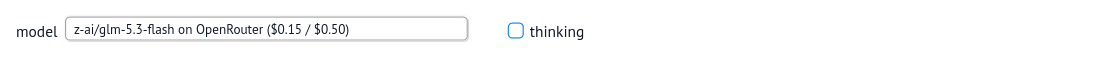

In [ ]:
# `MODEL=...` picks the entry, for running the notebook from a script. Otherwise
# the first entry, which is the one the measurements in the README recommend.
_default = next((k for k, m in MODELS.items() if m.id == os.environ.get("MODEL")), next(iter(MODELS)))
model_ui = mo.ui.dropdown(options=MODELS, value=_default, label="model")
thinking_ui = mo.ui.checkbox(value=False, label="thinking")
# Widgets only render in the editor; an export shows the status line below instead.
mo.hstack([model_ui, thinking_ui], justify="start", gap=2) if mo.app_meta().mode == "edit" else None

In [ ]:
# Changing the model re-runs every rung below. Pick it first.
MODEL = model_ui.value.id
EXTRA = {} if thinking_ui.value else model_ui.value.thinking_off
# Private, so the key reaches neither the dataflow graph nor any cell output.
_key = api_key(model_ui.value.key_var)
mo.stop(
    not _key,
    mo.md(f"🔑 Put `{model_ui.value.key_var}=...` in a `.env` beside the notebook.").callout("danger"),
)
# The environment is the interface to the code the model writes: its harness
# calls OpenAI() with no arguments, here and in the subprocesses we spawn.
os.environ["OPENAI_BASE_URL"] = model_ui.value.base_url
os.environ["OPENAI_API_KEY"] = _key
os.environ["MODEL"] = MODEL
os.environ["EXTRA_BODY"] = json.dumps(EXTRA)
client = OpenAI(timeout=240)
mo.md(f"✅ `{MODEL}` · thinking {'on' if thinking_ui.value else 'off'} · sends `extra_body={json.dumps(EXTRA)}`")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">✅ <code>z-ai/glm-5.3-flash</code> · thinking off · sends <code>extra_body={"reasoning": {"effort": "minimal"}}</code></span></span>

# Raytracing Saturn, bootstrapped

The same model, asked for the same picture, four times. Each time it gets
more machinery -- and each piece of machinery is written by the model
itself, one rung at a time, in front of you.

| rung | who decides what happens next | written by |
|---|---|---|
| 1. one shot | nobody: one request | us (about forty lines, below) |
| 2. the loop | the notebook: generate, run, review, repeat | the model, from a description |
| 3. the harness | the model: it has tools and picks the steps | the model, driven by its own loop |
| 4. the final render | the harness | -- |

This notebook *is* the conversation. A turn is one line, `turn("...")`, and
its reply renders underneath. A follow-up is `turn("...", after=t0)`, and
because that dependency is explicit, editing an early prompt re-runs every
turn that came after it. Code the model writes becomes importable with
`t.module("name")`, so nothing is pasted by hand.

Thinking is off by default so the rungs go fast. Tick the box and compare.
Changing the model or the box re-runs every rung below, so choose first.

## What we hand-roll

Four small things, and nothing else in this notebook is ours:

* `turn` -- one prompt to the model, streamed, with the conversation carried
  along explicitly. `permit` hands out the same thing without the display,
  for code the model writes to call.
* `run_render` and `run_test` -- how to *run* what the model wrote, each in a
  subprocess with a timeout and a memory cap. The first executes a raytracer
  and captures the array it returns; the second runs `harness_test.py`
  against a candidate harness. They are the *environment*. The model writes
  the *agent*.
* `run_harness` -- drives a model-written harness on a task and shows its
  progress.

One folder per sitting, a folder per model inside it, and a directory per
run inside that: `work/2026-09-14-124906/z-ai-glm-5.3-flash/render-4cn7veq8/`.
One thing per path segment. Re-running a cell never picks up the last run's
files, two models never mix, every round's output stays around to look at,
and a sitting is one folder you can hand over whole. A `Result` carries the
directory it used.

Everything slow or file-writing reports through `log`, which prints a line
and appends it to the `log.md` in that sitting's folder. Markdown, so a render
is linked next to the line about it and a sitting reads back as one page once
the kernel is gone. Those are the seams: every directory through `run_dir`, every report
through `log`, and every model call through `permit`.

`permit` is also the brake. It asks before anything is sent and then hands
back the function that sends it, so you can run cells at random and be
stopped at exactly the ones that cost time and money. Nothing else can reach
the model: the function it returns is private to that cell, so no other cell
can name it. An export has nobody to ask, so there it goes straight through.

In [ ]:
FENCE = re.compile(r"^```(?:python)?[ \t]*\n(.*?)^```[ \t]*$", re.S | re.M)
LOG = SESSION / "log.md"


def log(message: str, image: Path | None = None) -> None:
    """Every slow or file-writing step reports here: the cell console, and a log.md
    in this session's folder, which outlives the kernel. Markdown, so `image` can be
    linked where it was made and a sitting reads as one page of text and pictures."""
    line = f"{time.strftime('%H:%M:%S')}  {message}"
    print(line)
    with LOG.open("a") as handle:
        handle.write(f"- {line}\n")
        if image is not None:
            handle.write(f"\n  ![]({image.relative_to(SESSION)})\n\n")


def _ask(prompt: str, image: bytes | None = None, *, history=()) -> str:
    """One request, no display. `image` is PNG bytes the model should look at.

    Private on purpose: `permit` is the only way to get hold of this."""
    content = [{"type": "text", "text": prompt}]
    if image is not None:
        data = base64.standard_b64encode(image).decode()
        content.append({"type": "image_url", "image_url": {"url": f"data:image/png;base64,{data}"}})
    started = time.monotonic()
    reply = client.chat.completions.create(
        model=MODEL, messages=[*history, {"role": "user", "content": content}],
        max_tokens=16000, extra_body=EXTRA,
    )
    out = reply.usage.completion_tokens if reply.usage else "?"
    log(f"ask: {time.monotonic() - started:.0f}s, {out} tokens out{', with an image' if image else ''}")
    return reply.choices[0].message.content or ""


def permit(what: str = "this cell"):
    """Say yes before anything is sent, then get back the function that sends it.

    Every path to the model runs through here, so running cells at random stops
    at exactly the ones that cost time and money, and nowhere else. Handing the
    result to `loop` means the loop cannot be given a connection nobody agreed
    to. Outside the editor -- an export -- there is nobody to ask, so it goes."""
    if mo.app_meta().mode == "edit":
        if input(f"{what} will call {MODEL}. Type y to allow: ").strip().lower() != "y":
            raise RuntimeError(f"{what}: declined, nothing was sent")
    log(f"{what}: allowed to call {MODEL}")
    return _ask


def as_module(code: str, name: str):
    """Write `code` to work/<name>.py and import it, so the next cell can call into it."""
    path = WORK / f"{name}.py"
    path.write_text(code)
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


class Turn(NamedTuple):
    """One exchange. `history` is the whole conversation up to and including it."""

    prompt: str
    reply: str
    history: tuple

    @property
    def code(self) -> str:
        """The first python block in the reply."""
        return FENCE.search(self.reply).group(1)

    def module(self, name: str):
        return as_module(self.code, name)


def turn(prompt: str, after: Turn | None = None) -> Turn:
    """Send one prompt, streaming the reply into this cell's output."""
    permit("this turn")
    history = after.history if after else ()
    started = time.monotonic()
    stream = client.chat.completions.create(
        model=MODEL, messages=[*history, {"role": "user", "content": prompt}],
        max_tokens=16000, stream=True, extra_body=EXTRA,
    )
    reply, painted = "", 0.0
    for chunk in stream:
        if chunk.choices and chunk.choices[0].delta.content:
            reply += chunk.choices[0].delta.content
        if time.monotonic() - painted > 0.5:
            mo.output.replace(mo.md(reply))
            painted = time.monotonic()
    mo.output.replace(mo.md(reply))
    log(f"turn: {time.monotonic() - started:.0f}s, {len(reply)} characters back")
    return Turn(prompt, reply, (*history, {"role": "user", "content": prompt}, {"role": "assistant", "content": reply}))


class Png(NamedTuple):
    """A picture the notebook hands back. `_repr_png_` makes marimo emit a real
    image/png, which an export keeps."""

    data: bytes

    def _repr_png_(self) -> bytes:
        return self.data


class Result(NamedTuple):
    """What running the model's code produced. `image` is PNG bytes, or None."""

    stdout: str
    stderr: str
    image: bytes | None
    dir: Path  # where it ran, kept so you can go and look


# The whole id: two endpoints can offer the same model name.
RUN_ROOT = SESSION / re.sub(r"[^A-Za-z0-9._-]+", "-", MODEL)[:40]


def run_dir(label: str) -> Path:
    """A new directory per run: work/<sitting>/<model>/<what made it>-<unique>.

    One thing per path segment. Re-running a cell never sees the last run's
    files, two models never mix, and a sitting is one folder you can hand over
    whole. Every runner goes through here, so saying where it is once covers
    all of them."""
    RUN_ROOT.mkdir(parents=True, exist_ok=True)
    here = Path(tempfile.mkdtemp(dir=RUN_ROOT, prefix=f"{label}-"))
    log(f"{label}: {here.relative_to(SESSION)}/")
    return here


MEMORY_CAP_GB = 2  # a legitimate 800x600 render needs a few megabytes
# POSIX only; on Windows there is no cap. An over-allocation then fails as a
# numpy error naming the shape, which the reviewer reads and the model can act on.
CAP = "" if sys.platform == "win32" else (
    "import resource\n"
    f"_bytes = {MEMORY_CAP_GB} * 1024**3\n"
    "resource.setrlimit(resource.RLIMIT_AS, (_bytes, _bytes))\n"
)

RENDER_DRIVER = CAP + (
    "import numpy as np, saturn; from PIL import Image\n"
    "Image.fromarray(np.asarray(saturn.render()).astype('uint8')).save('out.png')"
)

TEST_DRIVER = CAP + "import runpy; runpy.run_path('harness_test.py', run_name='__main__')"


def run_render(code: str, timeout: int = 180) -> Result:
    """Run a raytracer that defines `render() -> HxWx3 uint8 array`, in a subprocess."""
    here = run_dir("render")
    (here / "saturn.py").write_text(code)
    try:
        done = subprocess.run(
            [sys.executable, "-c", RENDER_DRIVER], cwd=here, capture_output=True, text=True, timeout=timeout
        )
    except subprocess.TimeoutExpired:
        return Result("", f"killed after {timeout}s", None, here)
    png = here / "out.png"
    log(f"render: {'a picture' if png.exists() else 'no picture'}, {len(done.stderr)} characters on stderr",
        image=png if png.exists() else None)
    return Result(done.stdout[-4000:], done.stderr[-4000:], png.read_bytes() if png.exists() else None, here)


def run_test(code: str, timeout: int = 900) -> Result:
    """Run harness_test.py against a candidate harness. PASS or a failed assert is in the output."""
    here = run_dir("harness")
    (here / "my_harness.py").write_text(code)
    done = subprocess.run(
        [sys.executable, "-c", TEST_DRIVER, str(here / "my_harness.py")],
        cwd=WORK.parent, capture_output=True, text=True, timeout=timeout,
    )
    log(f"harness: {'PASS' if 'PASS' in done.stdout else 'no PASS'}")
    return Result(done.stdout[-4000:], done.stderr[-4000:], None, here)


def show(result: Result):
    """The image if there is one, else the output."""
    if result.image:
        return Png(result.image)
    return mo.md(f"```\n{result.stdout}\n{result.stderr}\n```").callout("warn")


def run_harness(agent_chat, task: str, where: Path):
    """Drive a model-written harness on `task` in `where`, showing its progress as it goes."""
    permit("this harness")  # it builds its own client, so it cannot go through `permit`
    from harness_test import Message

    lines = []
    with contextlib.chdir(where):  # the harness writes to the working directory
        gen = agent_chat([Message("user", task)], config={})
        while True:
            try:
                lines.append(next(gen))
            except StopIteration as done:
                mo.output.replace(mo.md("\n\n".join(lines)))
                return done.value  # the message list, if the harness returns one
            mo.output.replace(mo.md("\n\n".join(lines)))

## Rung 1 — one shot

One request. The contract is a function, not a file: `render()` returns the
picture as an array, and *we* decide what to do with it -- in a subprocess,
so an array the wrong shape costs us a subprocess and not the notebook.

If it fails, that is the exhibit. To try again, add a cell:
`t0b = turn("It failed with: ...", after=t0)` and point the next cell at it.

In [ ]:
SATURN = (
    "Write a Python module that raytraces Saturn -- an oblate planet with a ring "
    "system -- using only numpy. Define `render()` returning an 800x600x3 uint8 "
    "array. The rings must cast their shadows on the planet and the planet must "
    "cast its shadow on the rings. Vectorise with numpy; it must finish in under "
    "60 seconds. Reply with the complete module in one ```python block."
)

In [ ]:
t0 = turn(SATURN)

this turn will call z-ai/glm-5.3-flash. Type y to allow:  y
15:16:28  this turn: allowed to call z-ai/glm-5.3-flash
15:17:37  turn: 68s, 7522 characters back


<span class="markdown prose dark:prose-invert contents"><div class="language-python codehilite"><pre><span></span><code><span class="sd">"""</span>
<span class="sd">saturn.py -- a small, fully vectorised numpy raytracer for an oblate Saturn</span>
<span class="sd">with a banded ring system.  Rings shadow the planet and the planet shadows</span>
<span class="sd">the rings.  No external dependencies beyond numpy.</span>
<span class="sd">"""</span>

<span class="kn">import</span><span class="w"> </span><span class="nn">numpy</span><span class="w"> </span><span class="k">as</span><span class="w"> </span><span class="nn">np</span>

<span class="c1"># ----------------------------------------------------------------- constants</span>
<span class="n">W</span><span class="p">,</span> <span class="n">H</span> <span class="o">=</span> <span class="mi">800</span><span class="p">,</span> <span class="mi">600</span>                 <span class="c1"># render resolution</span>
<span class="n">RE</span><span class="p">,</span> <span class="n">RP</span> <span class="o">=</span> <span class="mf">1.0</span><span class="p">,</span> <span class="mf">0.55</span>              <span class="c1"># equatorial / polar radius of the planet</span>
<span class="n">RING_IN</span><span class="p">,</span> <span class="n">RING_OUT</span> <span class="o">=</span> <span class="mf">1.30</span><span class="p">,</span> <span class="mf">2.35</span>  <span class="c1"># ring annulus (planet radii)</span>
<span class="n">FOV</span> <span class="o">=</span> <span class="mf">0.55</span>                      <span class="c1"># half-height of view frustum at unit distance</span>

<span class="n">CAM</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.1</span><span class="p">,</span> <span class="o">-</span><span class="mf">3.7</span><span class="p">])</span>
<span class="n">SUN</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="o">-</span><span class="mf">0.9</span><span class="p">,</span> <span class="mf">0.45</span><span class="p">,</span> <span class="o">-</span><span class="mf">0.7</span><span class="p">])</span>
<span class="n">SUN</span> <span class="o">=</span> <span class="n">SUN</span> <span class="o">/</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">SUN</span><span class="p">)</span>

<span class="n">INV_SEMI</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">1.0</span> <span class="o">/</span> <span class="n">RE</span><span class="o">**</span><span class="mi">2</span><span class="p">,</span> <span class="mf">1.0</span> <span class="o">/</span> <span class="n">RP</span><span class="o">**</span><span class="mi">2</span><span class="p">,</span> <span class="mf">1.0</span> <span class="o">/</span> <span class="n">RE</span><span class="o">**</span><span class="mi">2</span><span class="p">])</span>  <span class="c1"># for normals</span>


<span class="c1"># ------------------------------------------------------------- ring profiles</span>
<span class="k">def</span><span class="w"> </span><span class="nf">_ring_opacity</span><span class="p">(</span><span class="n">r</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Optical thickness of the rings at radius r (np.select, vectorised)."""</span>
    <span class="n">a</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">zeros_like</span><span class="p">(</span><span class="n">r</span><span class="p">)</span>
    <span class="n">bands</span> <span class="o">=</span> <span class="p">[</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">1.30</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;</span> <span class="mf">1.65</span><span class="p">),</span> <span class="mf">0.30</span><span class="p">),</span>   <span class="c1"># C ring</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">1.65</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;</span> <span class="mf">2.05</span><span class="p">),</span> <span class="mf">0.95</span><span class="p">),</span>   <span class="c1"># B ring</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">2.05</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;</span> <span class="mf">2.15</span><span class="p">),</span> <span class="mf">0.03</span><span class="p">),</span>   <span class="c1"># Cassini division</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">2.15</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;=</span> <span class="mf">2.35</span><span class="p">),</span> <span class="mf">0.65</span><span class="p">),</span>  <span class="c1"># A ring</span>
    <span class="p">]</span>
    <span class="k">for</span> <span class="n">m</span><span class="p">,</span> <span class="n">v</span> <span class="ow">in</span> <span class="n">bands</span><span class="p">:</span>
        <span class="n">a</span><span class="p">[</span><span class="n">m</span><span class="p">]</span> <span class="o">=</span> <span class="n">v</span>
    <span class="n">a</span><span class="p">[</span><span class="n">np</span><span class="o">.</span><span class="n">abs</span><span class="p">(</span><span class="n">r</span> <span class="o">-</span> <span class="mf">2.27</span><span class="p">)</span> <span class="o">&lt;</span> <span class="mf">0.02</span><span class="p">]</span> <span class="o">=</span> <span class="mf">0.03</span>       <span class="c1"># Encke gap (applied last -&gt; wins)</span>
    <span class="k">return</span> <span class="n">a</span>


<span class="k">def</span><span class="w"> </span><span class="nf">_ring_color</span><span class="p">(</span><span class="n">r</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Albedo colour of the rings at radius r."""</span>
    <span class="n">col</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">full</span><span class="p">(</span><span class="n">r</span><span class="o">.</span><span class="n">shape</span> <span class="o">+</span> <span class="p">(</span><span class="mi">3</span><span class="p">,),</span> <span class="mf">0.70</span><span class="p">)</span>
    <span class="n">bands</span> <span class="o">=</span> <span class="p">[</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">1.30</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;</span> <span class="mf">1.65</span><span class="p">),</span> <span class="p">(</span><span class="mf">0.52</span><span class="p">,</span> <span class="mf">0.50</span><span class="p">,</span> <span class="mf">0.47</span><span class="p">)),</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">1.65</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;</span> <span class="mf">2.05</span><span class="p">),</span> <span class="p">(</span><span class="mf">0.84</span><span class="p">,</span> <span class="mf">0.75</span><span class="p">,</span> <span class="mf">0.60</span><span class="p">)),</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">2.05</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;</span> <span class="mf">2.15</span><span class="p">),</span> <span class="p">(</span><span class="mf">0.45</span><span class="p">,</span> <span class="mf">0.43</span><span class="p">,</span> <span class="mf">0.42</span><span class="p">)),</span>
        <span class="p">((</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="mf">2.15</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;=</span> <span class="mf">2.35</span><span class="p">),</span> <span class="p">(</span><span class="mf">0.76</span><span class="p">,</span> <span class="mf">0.70</span><span class="p">,</span> <span class="mf">0.58</span><span class="p">)),</span>
    <span class="p">]</span>
    <span class="k">for</span> <span class="n">m</span><span class="p">,</span> <span class="n">c</span> <span class="ow">in</span> <span class="n">bands</span><span class="p">:</span>
        <span class="n">col</span><span class="p">[</span><span class="n">m</span><span class="p">]</span> <span class="o">=</span> <span class="n">c</span>
    <span class="k">return</span> <span class="n">col</span>


<span class="c1"># ------------------------------------------------------------ planet texture</span>
<span class="k">def</span><span class="w"> </span><span class="nf">_planet_color</span><span class="p">(</span><span class="n">lat</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Banded cloud-deck colour.  lat = y/RP in [-1, 1] (sin of latitude)."""</span>
    <span class="n">a</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">abs</span><span class="p">(</span><span class="n">lat</span><span class="p">)</span>
    <span class="n">base_eq</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.86</span><span class="p">,</span> <span class="mf">0.76</span><span class="p">,</span> <span class="mf">0.55</span><span class="p">])</span>
    <span class="n">base_mid</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.76</span><span class="p">,</span> <span class="mf">0.66</span><span class="p">,</span> <span class="mf">0.46</span><span class="p">])</span>
    <span class="n">base_pol</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.66</span><span class="p">,</span> <span class="mf">0.62</span><span class="p">,</span> <span class="mf">0.55</span><span class="p">])</span>

    <span class="n">wm</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">exp</span><span class="p">(</span><span class="o">-</span><span class="p">((</span><span class="n">a</span> <span class="o">-</span> <span class="mf">0.35</span><span class="p">)</span> <span class="o">/</span> <span class="mf">0.28</span><span class="p">)</span> <span class="o">**</span> <span class="mi">2</span><span class="p">)</span>          <span class="c1"># mid-latitude mixing</span>
    <span class="n">wp</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">((</span><span class="n">a</span> <span class="o">-</span> <span class="mf">0.55</span><span class="p">)</span> <span class="o">/</span> <span class="mf">0.40</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>       <span class="c1"># polar hood</span>

    <span class="n">col</span> <span class="o">=</span> <span class="n">base_eq</span><span class="p">[</span><span class="kc">None</span><span class="p">,</span> <span class="p">:]</span> <span class="o">*</span> <span class="p">(</span><span class="mf">1.0</span> <span class="o">-</span> <span class="n">wm</span><span class="p">)[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">+</span> <span class="n">base_mid</span> <span class="o">*</span> <span class="n">wm</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>
    <span class="n">col</span> <span class="o">=</span> <span class="n">col</span> <span class="o">*</span> <span class="p">(</span><span class="mf">1.0</span> <span class="o">-</span> <span class="n">wp</span><span class="p">)[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">+</span> <span class="n">base_pol</span> <span class="o">*</span> <span class="n">wp</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>

    <span class="c1"># a few darker / brighter zonal bands</span>
    <span class="k">for</span> <span class="n">centre</span><span class="p">,</span> <span class="n">width</span><span class="p">,</span> <span class="n">amp</span> <span class="ow">in</span> <span class="p">((</span><span class="o">-</span><span class="mf">0.12</span><span class="p">,</span> <span class="mf">0.045</span><span class="p">,</span> <span class="mf">0.10</span><span class="p">),</span> <span class="p">(</span><span class="mf">0.06</span><span class="p">,</span> <span class="mf">0.03</span><span class="p">,</span> <span class="o">-</span><span class="mf">0.08</span><span class="p">),</span>
                               <span class="p">(</span><span class="mf">0.30</span><span class="p">,</span> <span class="mf">0.05</span><span class="p">,</span> <span class="mf">0.12</span><span class="p">),</span> <span class="p">(</span><span class="o">-</span><span class="mf">0.42</span><span class="p">,</span> <span class="mf">0.06</span><span class="p">,</span> <span class="o">-</span><span class="mf">0.10</span><span class="p">)):</span>
        <span class="n">g</span> <span class="o">=</span> <span class="n">amp</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">exp</span><span class="p">(</span><span class="o">-</span><span class="p">((</span><span class="n">lat</span> <span class="o">-</span> <span class="n">centre</span><span class="p">)</span> <span class="o">/</span> <span class="n">width</span><span class="p">)</span> <span class="o">**</span> <span class="mi">2</span><span class="p">)</span>
        <span class="n">col</span> <span class="o">*=</span> <span class="p">(</span><span class="mf">1.0</span> <span class="o">+</span> <span class="n">g</span><span class="p">)[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>
    <span class="k">return</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">col</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>


<span class="c1"># ------------------------------------------------------------ intersections</span>
<span class="k">def</span><span class="w"> </span><span class="nf">_spheroid_hit</span><span class="p">(</span><span class="n">o</span><span class="p">,</span> <span class="n">d</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Nearest positive ray-spheroid hit parameter t (inf = miss).</span>

<span class="sd">    o: (3,) origin, d: (..., 3) directions.  Works in y-scaled space so the</span>
<span class="sd">    oblate planet becomes a unit sphere.</span>
<span class="sd">    """</span>
    <span class="n">o_s</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="n">o</span><span class="p">[</span><span class="mi">0</span><span class="p">],</span> <span class="n">o</span><span class="p">[</span><span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">RP</span><span class="p">,</span> <span class="n">o</span><span class="p">[</span><span class="mi">2</span><span class="p">]])</span>
    <span class="n">d_s</span> <span class="o">=</span> <span class="n">d</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">1.0</span><span class="p">,</span> <span class="mf">1.0</span> <span class="o">/</span> <span class="n">RP</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">])</span>

    <span class="n">a</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">einsum</span><span class="p">(</span><span class="s1">'...i,...i-&gt;...'</span><span class="p">,</span> <span class="n">d_s</span><span class="p">,</span> <span class="n">d_s</span><span class="p">)</span>
    <span class="n">b</span> <span class="o">=</span> <span class="mf">2.0</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">einsum</span><span class="p">(</span><span class="s1">'...i,...i-&gt;...'</span><span class="p">,</span> <span class="n">o_s</span><span class="p">,</span> <span class="n">d_s</span><span class="p">)</span>
    <span class="n">c</span> <span class="o">=</span> <span class="n">o_s</span> <span class="o">@</span> <span class="n">o_s</span> <span class="o">-</span> <span class="mf">1.0</span>

    <span class="n">disc</span> <span class="o">=</span> <span class="n">b</span> <span class="o">*</span> <span class="n">b</span> <span class="o">-</span> <span class="mf">4.0</span> <span class="o">*</span> <span class="n">a</span> <span class="o">*</span> <span class="n">c</span>
    <span class="n">ok</span> <span class="o">=</span> <span class="n">disc</span> <span class="o">&gt;</span> <span class="mf">0.0</span>
    <span class="n">t</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">full</span><span class="p">(</span><span class="n">d</span><span class="o">.</span><span class="n">shape</span><span class="p">[:</span><span class="o">-</span><span class="mi">1</span><span class="p">],</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span>
    <span class="n">t_ok</span> <span class="o">=</span> <span class="p">(</span><span class="o">-</span><span class="n">b</span><span class="p">[</span><span class="n">ok</span><span class="p">]</span> <span class="o">-</span> <span class="n">np</span><span class="o">.</span><span class="n">sqrt</span><span class="p">(</span><span class="n">disc</span><span class="p">[</span><span class="n">ok</span><span class="p">]))</span> <span class="o">/</span> <span class="p">(</span><span class="mf">2.0</span> <span class="o">*</span> <span class="n">a</span><span class="p">[</span><span class="n">ok</span><span class="p">])</span>
    <span class="n">t_ok</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">t_ok</span> <span class="o">&gt;</span> <span class="mf">1e-4</span><span class="p">,</span> <span class="n">t_ok</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span>
    <span class="n">t</span><span class="p">[</span><span class="n">ok</span><span class="p">]</span> <span class="o">=</span> <span class="n">t_ok</span>
    <span class="k">return</span> <span class="n">t</span>


<span class="k">def</span><span class="w"> </span><span class="nf">_spheroid_normal</span><span class="p">(</span><span class="n">p</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Surface normal of the oblate spheroid at world point(s) p."""</span>
    <span class="n">n</span> <span class="o">=</span> <span class="n">p</span> <span class="o">*</span> <span class="n">INV_SEMI</span>
    <span class="n">n</span> <span class="o">/=</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">n</span><span class="p">,</span> <span class="n">axis</span><span class="o">=-</span><span class="mi">1</span><span class="p">,</span> <span class="n">keepdims</span><span class="o">=</span><span class="kc">True</span><span class="p">)</span>
    <span class="k">return</span> <span class="n">n</span>


<span class="k">def</span><span class="w"> </span><span class="nf">_ring_hit</span><span class="p">(</span><span class="n">o</span><span class="p">,</span> <span class="n">d</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Hit parameter and radius for rays crossing the ring plane y=0."""</span>
    <span class="k">with</span> <span class="n">np</span><span class="o">.</span><span class="n">errstate</span><span class="p">(</span><span class="n">divide</span><span class="o">=</span><span class="s1">'ignore'</span><span class="p">,</span> <span class="n">invalid</span><span class="o">=</span><span class="s1">'ignore'</span><span class="p">):</span>
        <span class="n">t</span> <span class="o">=</span> <span class="o">-</span><span class="n">o</span><span class="p">[</span><span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">d</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span>
    <span class="n">t</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">t</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">t</span> <span class="o">&gt;</span> <span class="mf">1e-4</span><span class="p">),</span> <span class="n">t</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span>
    <span class="n">q</span> <span class="o">=</span> <span class="n">o</span> <span class="o">+</span> <span class="n">t</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">d</span>
    <span class="n">r</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">hypot</span><span class="p">(</span><span class="n">q</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">0</span><span class="p">],</span> <span class="n">q</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">2</span><span class="p">])</span>
    <span class="n">valid</span> <span class="o">=</span> <span class="p">(</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="n">RING_IN</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;=</span> <span class="n">RING_OUT</span><span class="p">)</span>
    <span class="k">return</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">valid</span><span class="p">,</span> <span class="n">t</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">),</span> <span class="n">r</span>


<span class="c1"># ---------------------------------------------------------------- shading</span>
<span class="k">def</span><span class="w"> </span><span class="nf">_shade_planet</span><span class="p">(</span><span class="n">points</span><span class="p">,</span> <span class="n">normals</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Lambert shading + soft shadows cast by the rings."""</span>
    <span class="c1"># ring shadow: march the shadow ray (straight line towards the sun) to the</span>
    <span class="c1"># ring plane and multiply light by (1 - optical depth there)</span>
    <span class="k">with</span> <span class="n">np</span><span class="o">.</span><span class="n">errstate</span><span class="p">(</span><span class="n">divide</span><span class="o">=</span><span class="s1">'ignore'</span><span class="p">,</span> <span class="n">invalid</span><span class="o">=</span><span class="s1">'ignore'</span><span class="p">):</span>
        <span class="n">ts</span> <span class="o">=</span> <span class="o">-</span><span class="n">points</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">SUN</span><span class="p">[</span><span class="mi">1</span><span class="p">]</span>
    <span class="n">sp</span> <span class="o">=</span> <span class="n">points</span> <span class="o">+</span> <span class="n">ts</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">SUN</span>
    <span class="n">rs</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">hypot</span><span class="p">(</span><span class="n">sp</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">0</span><span class="p">],</span> <span class="n">sp</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">2</span><span class="p">])</span>
    <span class="n">crosses</span> <span class="o">=</span> <span class="p">(</span><span class="n">ts</span> <span class="o">&gt;</span> <span class="mf">1e-4</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">rs</span> <span class="o">&gt;=</span> <span class="n">RING_IN</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">rs</span> <span class="o">&lt;=</span> <span class="n">RING_OUT</span><span class="p">)</span>
    <span class="n">opacity</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">crosses</span><span class="p">,</span> <span class="n">_ring_opacity</span><span class="p">(</span><span class="n">rs</span><span class="p">),</span> <span class="mf">0.0</span><span class="p">)</span>
    <span class="n">light</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="mf">1.0</span> <span class="o">-</span> <span class="n">opacity</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>

    <span class="n">ndl</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">einsum</span><span class="p">(</span><span class="s1">'...i,...i-&gt;...'</span><span class="p">,</span> <span class="n">normals</span><span class="p">,</span> <span class="n">SUN</span><span class="p">),</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>
    <span class="n">lat</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">points</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">RP</span><span class="p">,</span> <span class="o">-</span><span class="mf">1.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>
    <span class="n">albedo</span> <span class="o">=</span> <span class="n">_planet_color</span><span class="p">(</span><span class="n">lat</span><span class="p">)</span>
    <span class="k">return</span> <span class="n">albedo</span> <span class="o">*</span> <span class="p">(</span><span class="mf">0.03</span> <span class="o">+</span> <span class="mf">0.97</span> <span class="o">*</span> <span class="n">ndl</span> <span class="o">*</span> <span class="n">light</span><span class="p">)[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>


<span class="k">def</span><span class="w"> </span><span class="nf">_shade_rings</span><span class="p">(</span><span class="n">points</span><span class="p">,</span> <span class="n">radii</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Ring colour, shadowed by the planet, composited over black space."""</span>
    <span class="n">alpha</span> <span class="o">=</span> <span class="n">_ring_opacity</span><span class="p">(</span><span class="n">radii</span><span class="p">)</span>
    <span class="n">col</span> <span class="o">=</span> <span class="n">_ring_color</span><span class="p">(</span><span class="n">radii</span><span class="p">)</span>

    <span class="c1"># planet shadow on the rings</span>
    <span class="n">in_shadow</span> <span class="o">=</span> <span class="n">_spheroid_hit</span><span class="p">(</span><span class="n">points</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">broadcast_to</span><span class="p">(</span><span class="n">SUN</span><span class="p">,</span> <span class="n">points</span><span class="o">.</span><span class="n">shape</span><span class="p">))</span> <span class="o">&lt;</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span>
    <span class="n">light</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">in_shadow</span><span class="p">,</span> <span class="mf">0.03</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>
    <span class="c1"># slight brightness variation with radius for depth</span>
    <span class="n">light</span> <span class="o">*=</span> <span class="p">(</span><span class="mf">0.75</span> <span class="o">+</span> <span class="mf">0.25</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">((</span><span class="n">RING_OUT</span> <span class="o">-</span> <span class="n">radii</span><span class="p">)</span> <span class="o">/</span>
                                    <span class="p">(</span><span class="n">RING_OUT</span> <span class="o">-</span> <span class="n">RING_IN</span><span class="p">),</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">))</span>
    <span class="k">return</span> <span class="n">col</span> <span class="o">*</span> <span class="n">light</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">],</span> <span class="n">alpha</span>


<span class="c1"># ------------------------------------------------------------------ render</span>
<span class="k">def</span><span class="w"> </span><span class="nf">render</span><span class="p">():</span>
<span class="w">    </span><span class="sd">"""Render the scene; returns an (800, 600, 3) uint8 RGB array."""</span>
    <span class="c1"># camera basis</span>
    <span class="n">fwd</span> <span class="o">=</span> <span class="o">-</span><span class="n">CAM</span> <span class="o">/</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">CAM</span><span class="p">)</span>
    <span class="n">right</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">cross</span><span class="p">(</span><span class="n">fwd</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">]))</span>
    <span class="n">right</span> <span class="o">/=</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">right</span><span class="p">)</span>
    <span class="n">up</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">cross</span><span class="p">(</span><span class="n">right</span><span class="p">,</span> <span class="n">fwd</span><span class="p">)</span>

    <span class="n">xs</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">arange</span><span class="p">(</span><span class="n">W</span><span class="p">)</span> <span class="o">-</span> <span class="n">W</span> <span class="o">/</span> <span class="mf">2.0</span> <span class="o">+</span> <span class="mf">0.5</span>
    <span class="n">ys</span> <span class="o">=</span> <span class="n">H</span> <span class="o">/</span> <span class="mf">2.0</span> <span class="o">-</span> <span class="n">np</span><span class="o">.</span><span class="n">arange</span><span class="p">(</span><span class="n">H</span><span class="p">)</span> <span class="o">-</span> <span class="mf">0.5</span>
    <span class="n">px</span><span class="p">,</span> <span class="n">py</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">meshgrid</span><span class="p">(</span><span class="n">xs</span> <span class="o">*</span> <span class="p">(</span><span class="n">FOV</span> <span class="o">*</span> <span class="n">W</span> <span class="o">/</span> <span class="n">H</span><span class="p">),</span> <span class="n">ys</span> <span class="o">*</span> <span class="n">FOV</span><span class="p">)</span>

    <span class="n">d</span> <span class="o">=</span> <span class="p">(</span><span class="n">fwd</span><span class="p">[</span><span class="kc">None</span><span class="p">,</span> <span class="kc">None</span><span class="p">,</span> <span class="p">:]</span> <span class="o">+</span> <span class="n">px</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">right</span> <span class="o">+</span> <span class="n">py</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">up</span><span class="p">)</span>
    <span class="n">d</span> <span class="o">/=</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">d</span><span class="p">,</span> <span class="n">axis</span><span class="o">=-</span><span class="mi">1</span><span class="p">,</span> <span class="n">keepdims</span><span class="o">=</span><span class="kc">True</span><span class="p">)</span>

    <span class="c1"># ---- geometry hits</span>
    <span class="n">t_planet</span> <span class="o">=</span> <span class="n">_spheroid_hit</span><span class="p">(</span><span class="n">CAM</span><span class="p">,</span> <span class="n">d</span><span class="p">)</span>
    <span class="n">t_ring</span><span class="p">,</span> <span class="n">r_ring</span> <span class="o">=</span> <span class="n">_ring_hit</span><span class="p">(</span><span class="n">CAM</span><span class="p">,</span> <span class="n">d</span><span class="p">)</span>

    <span class="n">p_planet</span> <span class="o">=</span> <span class="n">CAM</span> <span class="o">+</span> <span class="n">t_planet</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">d</span>
    <span class="n">p_ring</span> <span class="o">=</span> <span class="n">CAM</span> <span class="o">+</span> <span class="n">t_ring</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">d</span>

    <span class="c1"># ---- shading</span>
    <span class="n">planet_col</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">zeros</span><span class="p">((</span><span class="n">H</span><span class="p">,</span> <span class="n">W</span><span class="p">,</span> <span class="mi">3</span><span class="p">))</span>
    <span class="n">phit</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">t_planet</span><span class="p">)</span>
    <span class="k">if</span> <span class="n">phit</span><span class="o">.</span><span class="n">any</span><span class="p">():</span>
        <span class="n">nrm</span> <span class="o">=</span> <span class="n">_spheroid_normal</span><span class="p">(</span><span class="n">p_planet</span><span class="p">[</span><span class="n">phit</span><span class="p">])</span>
        <span class="n">planet_col</span><span class="p">[</span><span class="n">phit</span><span class="p">]</span> <span class="o">=</span> <span class="n">_shade_planet</span><span class="p">(</span><span class="n">p_planet</span><span class="p">[</span><span class="n">phit</span><span class="p">],</span> <span class="n">nrm</span><span class="p">)</span>

    <span class="n">ring_col</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">zeros</span><span class="p">((</span><span class="n">H</span><span class="p">,</span> <span class="n">W</span><span class="p">,</span> <span class="mi">3</span><span class="p">))</span>
    <span class="n">alpha</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">zeros</span><span class="p">((</span><span class="n">H</span><span class="p">,</span> <span class="n">W</span><span class="p">))</span>
    <span class="n">rhit</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">t_ring</span><span class="p">)</span>
    <span class="k">if</span> <span class="n">rhit</span><span class="o">.</span><span class="n">any</span><span class="p">():</span>
        <span class="n">rc</span><span class="p">,</span> <span class="n">al</span> <span class="o">=</span> <span class="n">_shade_rings</span><span class="p">(</span><span class="n">p_ring</span><span class="p">[</span><span class="n">rhit</span><span class="p">],</span> <span class="n">r_ring</span><span class="p">[</span><span class="n">rhit</span><span class="p">])</span>
        <span class="n">ring_col</span><span class="p">[</span><span class="n">rhit</span><span class="p">]</span> <span class="o">=</span> <span class="n">rc</span>
        <span class="n">alpha</span><span class="p">[</span><span class="n">rhit</span><span class="p">]</span> <span class="o">=</span> <span class="n">al</span>

    <span class="c1"># ---- composite: rings in front of the planet are semi-transparent</span>
    <span class="n">ring_in_front</span> <span class="o">=</span> <span class="n">rhit</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">t_ring</span> <span class="o">&lt;=</span> <span class="n">t_planet</span><span class="p">)</span>
    <span class="n">img</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">ring_in_front</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">],</span>
                   <span class="n">ring_col</span> <span class="o">*</span> <span class="n">alpha</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">+</span> <span class="n">planet_col</span> <span class="o">*</span> <span class="p">(</span><span class="mf">1.0</span> <span class="o">-</span> <span class="n">alpha</span><span class="p">)[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">],</span>
                   <span class="n">planet_col</span><span class="p">)</span>

    <span class="c1"># ---- sparse starfield</span>
    <span class="n">rng</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">default_rng</span><span class="p">(</span><span class="mi">7</span><span class="p">)</span>
    <span class="n">ns</span> <span class="o">=</span> <span class="mi">350</span>
    <span class="n">sy</span> <span class="o">=</span> <span class="n">rng</span><span class="o">.</span><span class="n">integers</span><span class="p">(</span><span class="mi">0</span><span class="p">,</span> <span class="n">H</span><span class="p">,</span> <span class="n">ns</span><span class="p">)</span>
    <span class="n">sx</span> <span class="o">=</span> <span class="n">rng</span><span class="o">.</span><span class="n">integers</span><span class="p">(</span><span class="mi">0</span><span class="p">,</span> <span class="n">W</span><span class="p">,</span> <span class="n">ns</span><span class="p">)</span>
    <span class="n">seen</span> <span class="o">=</span> <span class="o">~</span><span class="n">rhit</span><span class="p">[</span><span class="n">sy</span><span class="p">,</span> <span class="n">sx</span><span class="p">]</span>
    <span class="n">sy</span><span class="p">,</span> <span class="n">sx</span> <span class="o">=</span> <span class="n">sy</span><span class="p">[</span><span class="n">seen</span><span class="p">],</span> <span class="n">sx</span><span class="p">[</span><span class="n">seen</span><span class="p">]</span>
    <span class="n">bright</span> <span class="o">=</span> <span class="n">rng</span><span class="o">.</span><span class="n">uniform</span><span class="p">(</span><span class="mf">0.3</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">,</span> <span class="n">sy</span><span class="o">.</span><span class="n">size</span><span class="p">)</span>
    <span class="n">img</span><span class="p">[</span><span class="n">sy</span><span class="p">,</span> <span class="n">sx</span><span class="p">]</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">bright</span><span class="p">[:,</span> <span class="kc">None</span><span class="p">],</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>

    <span class="k">return</span> <span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">img</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span> <span class="o">*</span> <span class="mf">255.0</span><span class="p">)</span><span class="o">.</span><span class="n">astype</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">uint8</span><span class="p">)</span>


<span class="k">if</span> <span class="vm">__name__</span> <span class="o">==</span> <span class="s2">"__main__"</span><span class="p">:</span>
    <span class="kn">from</span><span class="w"> </span><span class="nn">time</span><span class="w"> </span><span class="kn">import</span> <span class="n">perf_counter</span>
    <span class="n">t0</span> <span class="o">=</span> <span class="n">perf_counter</span><span class="p">()</span>
    <span class="n">frame</span> <span class="o">=</span> <span class="n">render</span><span class="p">()</span>
    <span class="nb">print</span><span class="p">(</span><span class="sa">f</span><span class="s2">"rendered </span><span class="si">{</span><span class="n">W</span><span class="si">}</span><span class="s2">x</span><span class="si">{</span><span class="n">H</span><span class="si">}</span><span class="s2"> in </span><span class="si">{</span><span class="n">perf_counter</span><span class="p">()</span><span class="w"> </span><span class="o">-</span><span class="w"> </span><span class="n">t0</span><span class="si">:</span><span class="s2">.2f</span><span class="si">}</span><span class="s2"> s, "</span>
          <span class="sa">f</span><span class="s2">"dtype=</span><span class="si">{</span><span class="n">frame</span><span class="o">.</span><span class="n">dtype</span><span class="si">}</span><span class="s2">, shape=</span><span class="si">{</span><span class="n">frame</span><span class="o">.</span><span class="n">shape</span><span class="si">}</span><span class="s2">"</span><span class="p">)</span>
</code></pre></div></span>

15:17:37  render: z-ai-glm-5.3-flash/render-sa5dr625/
15:17:37  render: no picture, 920 characters on stderr


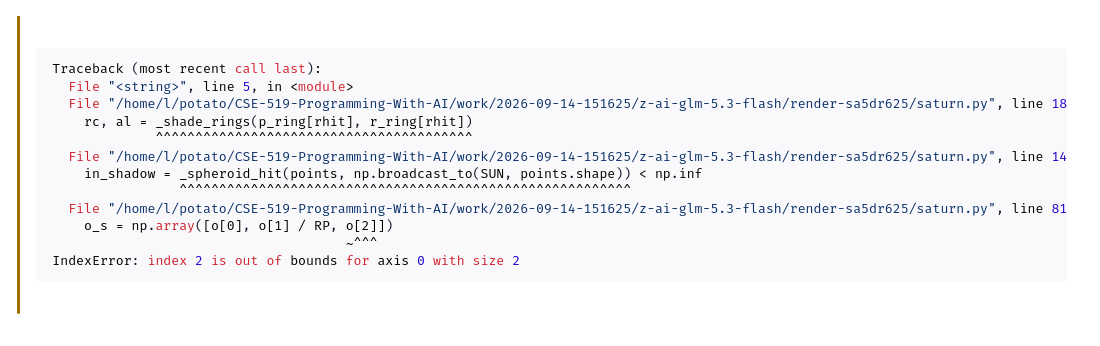

In [ ]:
result1 = run_render(t0.code) # This might fail (which is okay) as the model had to write the script with no feedback
show(result1)

## Rung 2 — the model writes the loop

Now describe a loop and let the model write it. The loop never gets tools.
The *notebook* decides what happens: generate, run, show the model what
happened, ask whether it is done, repeat. The model only ever answers
questions.

In [ ]:
LOOP_SPEC = """Write a Python function `loop(task, run, ask, max_rounds=8)` and nothing else:
no other top-level definitions, classes, or imports (import inside the function
if you must).

It is an iterative code-writing loop with no tools. The pieces it is given:
* `task`: a string describing a program to write.
* `run(code) -> Result`: executes the code and returns a NamedTuple with
  `.stdout`, `.stderr`, and `.image` (PNG bytes, or None).
* `ask(prompt, image=None) -> str`: sends one prompt to a language model,
  optionally with a PNG for it to look at, and returns the reply text.

Each round:
1. Ask the model for the code (the first round: the task; later rounds: the
   task, the previous code, and the reviewer's feedback). Extract the code
   from the first ```python block in the reply.
2. `run` it.
3. Ask the model to REVIEW: show it the code, the stdout and stderr, and the
   image if there is one -- and if there is none, say so explicitly. Tell it
   to reply with exactly the word DONE if the result fully satisfies the task,
   or otherwise a list of what must change; and tell it that a run which
   crashed with a traceback, or produced no image when the task asks for one,
   is never DONE. Warnings on stderr are not crashes.
4. If the reviewer's reply, ignoring surrounding whitespace, is DONE, stop.
   Otherwise carry the feedback into the next round. The loop itself never
   judges the result; only the reviewer's verdict decides.

Print one line per round saying what happened. Return `(code, result)` from
the last round. Reply with the function in one ```python block."""

In [ ]:
t1 = turn(LOOP_SPEC)

this turn will call z-ai/glm-5.3-flash. Type y to allow:  y
15:18:36  this turn: allowed to call z-ai/glm-5.3-flash
15:18:43  turn: 8s, 1836 characters back


<span class="markdown prose dark:prose-invert contents"><div class="language-python codehilite"><pre><span></span><code><span class="k">def</span><span class="w"> </span><span class="nf">loop</span><span class="p">(</span><span class="n">task</span><span class="p">,</span> <span class="n">run</span><span class="p">,</span> <span class="n">ask</span><span class="p">,</span> <span class="n">max_rounds</span><span class="o">=</span><span class="mi">8</span><span class="p">):</span>
    <span class="kn">import</span><span class="w"> </span><span class="nn">re</span>

    <span class="k">def</span><span class="w"> </span><span class="nf">extract</span><span class="p">(</span><span class="n">reply</span><span class="p">):</span>
        <span class="n">m</span> <span class="o">=</span> <span class="n">re</span><span class="o">.</span><span class="n">search</span><span class="p">(</span><span class="sa">r</span><span class="s2">"```python\s*\n(.*?)```"</span><span class="p">,</span> <span class="n">reply</span><span class="p">,</span> <span class="n">re</span><span class="o">.</span><span class="n">DOTALL</span><span class="p">)</span>
        <span class="k">return</span> <span class="n">m</span><span class="o">.</span><span class="n">group</span><span class="p">(</span><span class="mi">1</span><span class="p">)</span> <span class="k">if</span> <span class="n">m</span> <span class="k">else</span> <span class="kc">None</span>

    <span class="n">code</span> <span class="o">=</span> <span class="kc">None</span>
    <span class="n">result</span> <span class="o">=</span> <span class="kc">None</span>
    <span class="n">feedback</span> <span class="o">=</span> <span class="kc">None</span>

    <span class="k">for</span> <span class="n">round_num</span> <span class="ow">in</span> <span class="nb">range</span><span class="p">(</span><span class="mi">1</span><span class="p">,</span> <span class="n">max_rounds</span> <span class="o">+</span> <span class="mi">1</span><span class="p">):</span>
        <span class="k">if</span> <span class="n">round_num</span> <span class="o">==</span> <span class="mi">1</span><span class="p">:</span>
            <span class="n">prompt</span> <span class="o">=</span> <span class="n">task</span>
        <span class="k">else</span><span class="p">:</span>
            <span class="n">prompt</span> <span class="o">=</span> <span class="p">(</span>
                <span class="n">task</span>

                <span class="o">+</span> <span class="s2">"</span><span class="se">\n\n</span><span class="s2">Previous code:</span><span class="se">\n</span><span class="s2">```python</span><span class="se">\n</span><span class="s2">"</span> <span class="o">+</span> <span class="n">code</span> <span class="o">+</span> <span class="s2">"</span><span class="se">\n</span><span class="s2">```</span><span class="se">\n</span><span class="s2">"</span>

                <span class="o">+</span> <span class="s2">"Reviewer feedback (apply it):</span><span class="se">\n</span><span class="s2">"</span> <span class="o">+</span> <span class="n">feedback</span>
            <span class="p">)</span>
        <span class="n">code</span> <span class="o">=</span> <span class="n">extract</span><span class="p">(</span><span class="n">ask</span><span class="p">(</span><span class="n">prompt</span><span class="p">))</span>

        <span class="n">result</span> <span class="o">=</span> <span class="n">run</span><span class="p">(</span><span class="n">code</span><span class="p">)</span>
        <span class="n">has_image</span> <span class="o">=</span> <span class="n">result</span><span class="o">.</span><span class="n">image</span> <span class="ow">is</span> <span class="ow">not</span> <span class="kc">None</span>

        <span class="n">review_prompt</span> <span class="o">=</span> <span class="p">(</span>
            <span class="s2">"Task:</span><span class="se">\n</span><span class="s2">"</span> <span class="o">+</span> <span class="n">task</span>

            <span class="o">+</span> <span class="s2">"</span><span class="se">\n\n</span><span class="s2">Code:</span><span class="se">\n</span><span class="s2">```python</span><span class="se">\n</span><span class="s2">"</span> <span class="o">+</span> <span class="n">code</span> <span class="o">+</span> <span class="s2">"</span><span class="se">\n</span><span class="s2">```</span><span class="se">\n</span><span class="s2">"</span>

            <span class="o">+</span> <span class="s2">"</span><span class="se">\n</span><span class="s2">stdout:</span><span class="se">\n</span><span class="s2">"</span> <span class="o">+</span> <span class="p">(</span><span class="n">result</span><span class="o">.</span><span class="n">stdout</span> <span class="ow">or</span> <span class="s2">"(empty)"</span><span class="p">)</span>

            <span class="o">+</span> <span class="s2">"</span><span class="se">\n\n</span><span class="s2">stderr:</span><span class="se">\n</span><span class="s2">"</span> <span class="o">+</span> <span class="p">(</span><span class="n">result</span><span class="o">.</span><span class="n">stderr</span> <span class="ow">or</span> <span class="s2">"(empty)"</span><span class="p">)</span>

            <span class="o">+</span> <span class="p">(</span><span class="s2">"</span><span class="se">\n\n</span><span class="s2">An image was produced (attached)."</span>
               <span class="k">if</span> <span class="n">has_image</span> <span class="k">else</span>
               <span class="s2">"</span><span class="se">\n\n</span><span class="s2">No image was produced."</span><span class="p">)</span>

            <span class="o">+</span> <span class="s2">"</span><span class="se">\n\n</span><span class="s2">Review whether the result fully satisfies the task. "</span>
              <span class="s2">"Reply with exactly the word DONE if it does, otherwise reply "</span>
              <span class="s2">"with a list of what must change. A run that crashed with a "</span>
              <span class="s2">"traceback, or that produced no image when the task asks for "</span>
              <span class="s2">"one, is never DONE. Warnings on stderr are not crashes."</span>
        <span class="p">)</span>
        <span class="n">review</span> <span class="o">=</span> <span class="n">ask</span><span class="p">(</span><span class="n">review_prompt</span><span class="p">,</span> <span class="n">image</span><span class="o">=</span><span class="n">result</span><span class="o">.</span><span class="n">image</span><span class="p">)</span>

        <span class="k">if</span> <span class="n">review</span><span class="o">.</span><span class="n">strip</span><span class="p">()</span> <span class="o">==</span> <span class="s2">"DONE"</span><span class="p">:</span>
            <span class="nb">print</span><span class="p">(</span><span class="sa">f</span><span class="s2">"Round </span><span class="si">{</span><span class="n">round_num</span><span class="si">}</span><span class="s2">: DONE — reviewer accepted the result."</span><span class="p">)</span>
            <span class="k">return</span> <span class="p">(</span><span class="n">code</span><span class="p">,</span> <span class="n">result</span><span class="p">)</span>

        <span class="n">feedback</span> <span class="o">=</span> <span class="n">review</span>
        <span class="nb">print</span><span class="p">(</span><span class="sa">f</span><span class="s2">"Round </span><span class="si">{</span><span class="n">round_num</span><span class="si">}</span><span class="s2">: changes requested — carrying feedback into next round."</span><span class="p">)</span>

    <span class="nb">print</span><span class="p">(</span><span class="sa">f</span><span class="s2">"Reached max_rounds=</span><span class="si">{</span><span class="n">max_rounds</span><span class="si">}</span><span class="s2"> without DONE."</span><span class="p">)</span>
    <span class="k">return</span> <span class="p">(</span><span class="n">code</span><span class="p">,</span> <span class="n">result</span><span class="p">)</span>
</code></pre></div></span>

rung 2 will call z-ai/glm-5.3-flash. Type y to allow:  y
15:18:46  rung 2: allowed to call z-ai/glm-5.3-flash
15:20:51  ask: 125s, 10449 tokens out
15:20:51  render: z-ai-glm-5.3-flash/render-e6bc9old/
15:20:53  render: a picture, 0 characters on stderr
15:21:06  ask: 13s, 334 tokens out, with an image
Round 1: DONE — reviewer accepted the result.


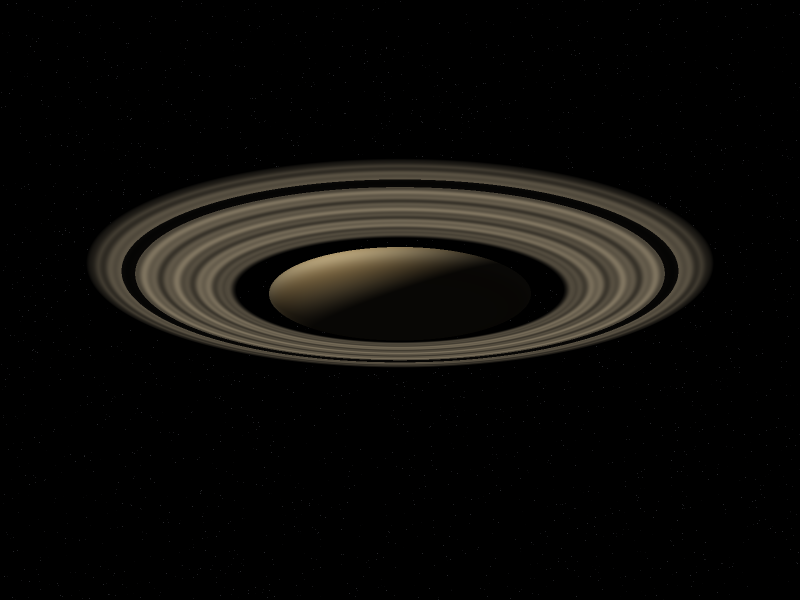

In [ ]:
loop = t1.module("loop").loop
code2, result2 = loop(SATURN, run_render, permit("rung 2"))
show(result2)

## Rung 3 — the loop writes the harness

Same loop, different task: write an agent *with* tools. The run step is now
`harness_test.py`, which is both the acceptance test and the interface: a
candidate passes when its tools really execute, which it proves by creating
a file with the right contents. The reviewer reads PASS or a failed assert.

This is the first rung where the model decides its own steps. Read what it
wrote: that is an agentic loop.

In [ ]:
# The contract, shown where it is used. The file stays the single definition:
# it is read as text here, run as a script by run_test, and imported for its
# Message by run_harness, and those three must not drift apart.
mo.md(f"""
Here is that test, `harness_test.py`:

<details><summary>the interface a harness must satisfy</summary>

```python
{(HERE / "harness_test.py").read_text().replace(chr(10), chr(10) + "    ")}
```

</details>""")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Here is that test, <code>harness_test.py</code>:</span>
<details><summary>the interface a harness must satisfy</summary>

<div class="language-python codehilite"><pre><span></span><code><span class="sd">"""The contract a harness must satisfy to plug into `mo.ui.chat`.</span>

<span class="sd">        python3 harness_test.py my_harness.py        # prints PASS or a failed assertion</span>

<span class="sd">    A harness is a module defining `agent_chat(messages, config)`: a generator that</span>
<span class="sd">    yields progress as strings, drives a model with tools until the task is done,</span>
<span class="sd">    and may `return` the OpenAI-shaped message list it built. It passes when its</span>
<span class="sd">    tools really ran, which it proves by creating a file with the right contents.</span>
<span class="sd">    """</span>

    <span class="kn">import</span><span class="w"> </span><span class="nn">importlib.util</span>
    <span class="kn">import</span><span class="w"> </span><span class="nn">itertools</span>
    <span class="kn">import</span><span class="w"> </span><span class="nn">os</span>
    <span class="kn">import</span><span class="w"> </span><span class="nn">sys</span>
    <span class="kn">import</span><span class="w"> </span><span class="nn">tempfile</span>
    <span class="kn">from</span><span class="w"> </span><span class="nn">dataclasses</span><span class="w"> </span><span class="kn">import</span> <span class="n">dataclass</span><span class="p">,</span> <span class="n">field</span>
    <span class="kn">from</span><span class="w"> </span><span class="nn">pathlib</span><span class="w"> </span><span class="kn">import</span> <span class="n">Path</span>


    <span class="nd">@dataclass</span>
    <span class="k">class</span><span class="w"> </span><span class="nc">Message</span><span class="p">:</span>
<span class="w">        </span><span class="sd">"""What marimo's chat widget actually hands over. Use `role` and `content`."""</span>

        <span class="n">role</span><span class="p">:</span> <span class="nb">str</span>
        <span class="n">content</span><span class="p">:</span> <span class="nb">str</span>
        <span class="nb">id</span><span class="p">:</span> <span class="nb">str</span> <span class="o">=</span> <span class="s2">"m1"</span>
        <span class="n">parts</span><span class="p">:</span> <span class="nb">list</span> <span class="o">=</span> <span class="n">field</span><span class="p">(</span><span class="n">default_factory</span><span class="o">=</span><span class="nb">list</span><span class="p">)</span>
        <span class="n">attachments</span><span class="p">:</span> <span class="nb">list</span> <span class="o">|</span> <span class="kc">None</span> <span class="o">=</span> <span class="kc">None</span>


    <span class="n">TASK</span> <span class="o">=</span> <span class="s2">"Create a file called hello.py containing exactly this line: print('generated harness works')"</span>


    <span class="k">def</span><span class="w"> </span><span class="nf">test_harness</span><span class="p">(</span><span class="n">agent_chat</span><span class="p">):</span>
        <span class="n">stream</span> <span class="o">=</span> <span class="n">agent_chat</span><span class="p">([</span><span class="n">Message</span><span class="p">(</span><span class="s2">"user"</span><span class="p">,</span> <span class="n">TASK</span><span class="p">)],</span> <span class="n">config</span><span class="o">=</span><span class="p">{})</span>
        <span class="n">yields</span> <span class="o">=</span> <span class="p">[]</span>
        <span class="k">try</span><span class="p">:</span>
            <span class="k">for</span> <span class="n">chunk</span> <span class="ow">in</span> <span class="n">itertools</span><span class="o">.</span><span class="n">islice</span><span class="p">(</span><span class="n">stream</span><span class="p">,</span> <span class="mi">400</span><span class="p">):</span>
                <span class="n">yields</span><span class="o">.</span><span class="n">append</span><span class="p">(</span><span class="n">chunk</span><span class="p">)</span>
        <span class="k">except</span> <span class="ne">StopIteration</span><span class="p">:</span>
            <span class="k">pass</span>
        <span class="k">assert</span> <span class="n">yields</span><span class="p">,</span> <span class="s2">"must yield at least one progress string"</span>
        <span class="k">assert</span> <span class="nb">all</span><span class="p">(</span><span class="nb">isinstance</span><span class="p">(</span><span class="n">y</span><span class="p">,</span> <span class="nb">str</span><span class="p">)</span> <span class="k">for</span> <span class="n">y</span> <span class="ow">in</span> <span class="n">yields</span><span class="p">),</span> <span class="sa">f</span><span class="s2">"every yield must be a str, got </span><span class="si">{</span><span class="nb">type</span><span class="p">(</span><span class="n">yields</span><span class="p">[</span><span class="o">-</span><span class="mi">1</span><span class="p">])</span><span class="o">.</span><span class="vm">__name__</span><span class="si">}</span><span class="s2">"</span>
        <span class="k">assert</span> <span class="nb">len</span><span class="p">(</span><span class="n">yields</span><span class="p">)</span> <span class="o">&lt;</span> <span class="mi">400</span><span class="p">,</span> <span class="s2">"did not stop within 400 yields"</span>
        <span class="n">hello</span> <span class="o">=</span> <span class="n">Path</span><span class="p">(</span><span class="s2">"hello.py"</span><span class="p">)</span>
        <span class="k">assert</span> <span class="n">hello</span><span class="o">.</span><span class="n">exists</span><span class="p">(),</span> <span class="s2">"hello.py was never created: the tools did not run"</span>
        <span class="k">assert</span> <span class="s2">"generated harness works"</span> <span class="ow">in</span> <span class="n">hello</span><span class="o">.</span><span class="n">read_text</span><span class="p">(),</span> <span class="sa">f</span><span class="s2">"hello.py says </span><span class="si">{</span><span class="n">hello</span><span class="o">.</span><span class="n">read_text</span><span class="p">()[:</span><span class="mi">60</span><span class="p">]</span><span class="si">!r}</span><span class="s2">"</span>


    <span class="k">def</span><span class="w"> </span><span class="nf">load</span><span class="p">(</span><span class="n">path</span><span class="p">):</span>
        <span class="n">spec</span> <span class="o">=</span> <span class="n">importlib</span><span class="o">.</span><span class="n">util</span><span class="o">.</span><span class="n">spec_from_file_location</span><span class="p">(</span><span class="s2">"candidate"</span><span class="p">,</span> <span class="n">path</span><span class="p">)</span>
        <span class="n">module</span> <span class="o">=</span> <span class="n">importlib</span><span class="o">.</span><span class="n">util</span><span class="o">.</span><span class="n">module_from_spec</span><span class="p">(</span><span class="n">spec</span><span class="p">)</span>
        <span class="n">spec</span><span class="o">.</span><span class="n">loader</span><span class="o">.</span><span class="n">exec_module</span><span class="p">(</span><span class="n">module</span><span class="p">)</span>
        <span class="k">return</span> <span class="n">module</span>


    <span class="k">if</span> <span class="vm">__name__</span> <span class="o">==</span> <span class="s2">"__main__"</span><span class="p">:</span>
        <span class="n">candidate</span> <span class="o">=</span> <span class="n">Path</span><span class="p">(</span><span class="n">sys</span><span class="o">.</span><span class="n">argv</span><span class="p">[</span><span class="mi">1</span><span class="p">])</span><span class="o">.</span><span class="n">resolve</span><span class="p">()</span>
        <span class="n">workdir</span> <span class="o">=</span> <span class="n">tempfile</span><span class="o">.</span><span class="n">mkdtemp</span><span class="p">(</span><span class="n">prefix</span><span class="o">=</span><span class="s2">"harness-test-"</span><span class="p">)</span>
        <span class="n">os</span><span class="o">.</span><span class="n">chdir</span><span class="p">(</span><span class="n">workdir</span><span class="p">)</span>  <span class="c1"># the harness writes to the current directory</span>
        <span class="n">test_harness</span><span class="p">(</span><span class="n">load</span><span class="p">(</span><span class="n">candidate</span><span class="p">)</span><span class="o">.</span><span class="n">agent_chat</span><span class="p">)</span>
        <span class="nb">print</span><span class="p">(</span><span class="sa">f</span><span class="s2">"PASS: </span><span class="si">{</span><span class="n">candidate</span><span class="o">.</span><span class="n">name</span><span class="si">}</span><span class="s2">"</span><span class="p">)</span>
</code></pre></div>

</details></span>

In [ ]:
HARNESS_SPEC = f"""Write a Python module that implements a coding agent with tools, and nothing else.
It must pass this test, which is also the interface -- read it:

```python
{(HERE / "harness_test.py").read_text()}
```

Yield one short progress line per tool call -- the tool's name and its `path`
argument only, never file contents -- each ending in a newline, then
the model's final answer, and `return` the message list you built. Everything
the agent writes goes in the current working directory.

Use the `openai` package's chat completions API with tool calling. The client
is `OpenAI()` with no arguments -- OPENAI_BASE_URL and OPENAI_API_KEY are set in
the environment -- and the model name is in the MODEL environment variable.
Pass `extra_body=json.loads(os.environ.get("EXTRA_BODY", "{{}}"))` on every request.

Give the model three tools: `write_file(path, content)`, `run_python(path)`
(returns exit code, stdout, stderr), and `look_at(path)` for a PNG, whose
text result must state the image's width and height in pixels. A tool
message can only carry text, so for `look_at` return a short note as the tool
result and then append a user message with the image as a base64 data URL.
Loop: request with tools, execute every tool call, append the results, repeat
until the model replies without tool calls or 25 turns pass.

Reply with the module in one ```python block."""

In [ ]:
code3, result3 = loop(HARNESS_SPEC, run_test, permit("rung 3"))
print(result3.stdout)

rung 3 will call z-ai/glm-5.3-flash. Type y to allow:  y
15:21:09  rung 3: allowed to call z-ai/glm-5.3-flash
15:21:19  ask: 10s, 1083 tokens out
15:21:19  harness: z-ai-glm-5.3-flash/harness-q1534s8i/
15:21:38  harness: PASS
15:21:39  ask: 1s, 3 tokens out
Round 1: DONE — reviewer accepted the result.
PASS: my_harness.py



## Rung 4 — Saturn, one last time

The harness the model wrote, on the original task. Watch for the moment it
calls `look_at` and then changes something.

In [ ]:
agent_chat = as_module(code3, "harness").agent_chat
SATURN_FILE = SATURN.replace("using only numpy", "using only numpy and Pillow").replace(
    "Define `render()` returning an 800x600x3 uint8 array", "Save it as saturn.png")
SATURN_DIR = run_dir("saturn")  # empty, so the picture below can only be this run's
transcript = run_harness(agent_chat, SATURN_FILE, SATURN_DIR)

15:21:39  saturn: z-ai-glm-5.3-flash/saturn-kym3irwo/
this harness will call z-ai/glm-5.3-flash. Type y to allow:  y
15:22:09  this harness: allowed to call z-ai/glm-5.3-flash


<span class="markdown prose dark:prose-invert contents"><span class="paragraph">write_file saturn_raytrace.py</span>
<span class="paragraph">run_python saturn_raytrace.py</span>
<span class="paragraph">write_file saturn_raytrace.py</span>
<span class="paragraph">run_python saturn_raytrace.py</span>
<span class="paragraph">run_python fix.py</span>
<span class="paragraph">write_file fix.py</span>
<span class="paragraph">run_python fix.py</span>
<span class="paragraph">run_python saturn_raytrace.py</span>
<span class="paragraph">write_file fix.py</span>
<span class="paragraph">run_python fix.py</span>
<span class="paragraph">run_python saturn_raytrace.py</span>
<span class="paragraph">look_at saturn.png</span>
<span class="paragraph">write_file fix.py</span>
<span class="paragraph">run_python fix.py</span>
<span class="paragraph">run_python saturn_raytrace.py</span>
<span class="paragraph">look_at saturn.png</span>
<span class="paragraph">write_file fix.py</span>
<span class="paragraph">run_python fix.py</span>
<span class="paragraph">run_python saturn_raytrace.py</span>
<span class="paragraph">look_at saturn.png</span>
<span class="paragraph">The render looks great — both shadows are visible (planet shadow across the rings, ring shadow band on the globe). Renders in ~5s. Here's the final module:</span>
<div class="language-python codehilite"><pre><span></span><code><span class="sd">"""</span>
<span class="sd">Raytraced Saturn: oblate planet + ring system, numpy-vectorised.</span>
<span class="sd">Rings shadow the planet; the planet shadows the rings.</span>
<span class="sd">Requires: numpy, Pillow.  Output: saturn.png</span>
<span class="sd">"""</span>
<span class="kn">import</span><span class="w"> </span><span class="nn">time</span>
<span class="kn">import</span><span class="w"> </span><span class="nn">numpy</span><span class="w"> </span><span class="k">as</span><span class="w"> </span><span class="nn">np</span>
<span class="kn">from</span><span class="w"> </span><span class="nn">PIL</span><span class="w"> </span><span class="kn">import</span> <span class="n">Image</span>

<span class="n">W</span><span class="p">,</span> <span class="n">H</span> <span class="o">=</span> <span class="mi">900</span><span class="p">,</span> <span class="mi">675</span>          <span class="c1"># output resolution</span>
<span class="n">SS</span> <span class="o">=</span> <span class="mi">2</span>                   <span class="c1"># supersampling factor (2x2 per pixel)</span>
<span class="n">OBLATE</span> <span class="o">=</span> <span class="mf">0.918</span>           <span class="c1"># polar / equatorial radius ratio of Saturn</span>

<span class="c1"># ---------------------------------------------------------------- geometry --</span>
<span class="k">def</span><span class="w"> </span><span class="nf">normalize</span><span class="p">(</span><span class="n">v</span><span class="p">):</span>
    <span class="k">return</span> <span class="n">v</span> <span class="o">/</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">v</span><span class="p">)</span>

<span class="c1"># Camera (orthographic, gently tilted down)</span>
<span class="n">D</span> <span class="o">=</span> <span class="n">normalize</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.05</span><span class="p">,</span> <span class="o">-</span><span class="mf">0.32</span><span class="p">,</span> <span class="o">-</span><span class="mf">1.0</span><span class="p">]))</span>      <span class="c1"># view direction (cam -&gt; scene)</span>
<span class="n">R</span> <span class="o">=</span> <span class="n">normalize</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">cross</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">]),</span> <span class="n">D</span><span class="p">))</span>
<span class="n">U</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">cross</span><span class="p">(</span><span class="n">D</span><span class="p">,</span> <span class="n">R</span><span class="p">)</span>

<span class="c1"># Sun direction (unit, points *towards* the sun)</span>
<span class="n">L</span> <span class="o">=</span> <span class="n">normalize</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.40</span><span class="p">,</span> <span class="mf">0.35</span><span class="p">,</span> <span class="mf">0.55</span><span class="p">]))</span>

<span class="c1"># Ring bands: (inner_r, outer_r, opacity, tint)</span>
<span class="n">RING_BANDS</span> <span class="o">=</span> <span class="p">[</span>
    <span class="p">(</span><span class="mf">1.24</span><span class="p">,</span> <span class="mf">1.53</span><span class="p">,</span> <span class="mf">0.75</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.78</span><span class="p">,</span> <span class="mf">0.70</span><span class="p">,</span> <span class="mf">0.56</span><span class="p">])),</span>   <span class="c1"># C ring (dim)</span>
    <span class="p">(</span><span class="mf">1.53</span><span class="p">,</span> <span class="mf">1.95</span><span class="p">,</span> <span class="mf">0.95</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.90</span><span class="p">,</span> <span class="mf">0.82</span><span class="p">,</span> <span class="mf">0.62</span><span class="p">])),</span>   <span class="c1"># B ring (bright)</span>
    <span class="p">(</span><span class="mf">1.95</span><span class="p">,</span> <span class="mf">2.03</span><span class="p">,</span> <span class="mf">0.06</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.85</span><span class="p">,</span> <span class="mf">0.80</span><span class="p">,</span> <span class="mf">0.70</span><span class="p">])),</span>   <span class="c1"># Cassini division</span>
    <span class="p">(</span><span class="mf">2.03</span><span class="p">,</span> <span class="mf">2.27</span><span class="p">,</span> <span class="mf">0.85</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.82</span><span class="p">,</span> <span class="mf">0.76</span><span class="p">,</span> <span class="mf">0.60</span><span class="p">])),</span>   <span class="c1"># A ring</span>
    <span class="p">(</span><span class="mf">2.27</span><span class="p">,</span> <span class="mf">2.32</span><span class="p">,</span> <span class="mf">0.25</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.80</span><span class="p">,</span> <span class="mf">0.75</span><span class="p">,</span> <span class="mf">0.62</span><span class="p">])),</span>   <span class="c1"># F ring hint</span>
<span class="p">]</span>

<span class="k">def</span><span class="w"> </span><span class="nf">ring_opacity</span><span class="p">(</span><span class="n">r</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Opacity + colour of rings at radius r (vectorised)."""</span>
    <span class="n">r</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">r</span><span class="p">),</span> <span class="n">r</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">)</span>
    <span class="n">op</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">zeros_like</span><span class="p">(</span><span class="n">r</span><span class="p">)</span>
    <span class="n">col</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">zeros</span><span class="p">(</span><span class="n">r</span><span class="o">.</span><span class="n">shape</span> <span class="o">+</span> <span class="p">(</span><span class="mi">3</span><span class="p">,))</span>
    <span class="k">for</span> <span class="n">r0</span><span class="p">,</span> <span class="n">r1</span><span class="p">,</span> <span class="n">o</span><span class="p">,</span> <span class="n">c</span> <span class="ow">in</span> <span class="n">RING_BANDS</span><span class="p">:</span>
        <span class="n">m</span> <span class="o">=</span> <span class="p">(</span><span class="n">r</span> <span class="o">&gt;=</span> <span class="n">r0</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">r</span> <span class="o">&lt;</span> <span class="n">r1</span><span class="p">)</span>
        <span class="n">op</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">m</span><span class="p">,</span> <span class="n">o</span><span class="p">,</span> <span class="n">op</span><span class="p">)</span>
        <span class="n">col</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">m</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">],</span> <span class="n">c</span><span class="p">,</span> <span class="n">col</span><span class="p">)</span>
    <span class="c1"># fine radial grooves for texture</span>
    <span class="n">grooves</span> <span class="o">=</span> <span class="mf">0.82</span> <span class="o">+</span> <span class="mf">0.18</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">sin</span><span class="p">(</span><span class="n">r</span> <span class="o">*</span> <span class="mf">210.0</span><span class="p">)</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="mf">1.0</span> <span class="o">-</span> <span class="n">np</span><span class="o">.</span><span class="n">abs</span><span class="p">(</span><span class="n">r</span> <span class="o">-</span> <span class="mf">1.74</span><span class="p">),</span> <span class="mi">0</span><span class="p">,</span> <span class="mi">1</span><span class="p">)</span>
    <span class="n">op</span> <span class="o">=</span> <span class="n">op</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">grooves</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>
    <span class="k">return</span> <span class="n">op</span><span class="p">,</span> <span class="n">col</span>

<span class="k">def</span><span class="w"> </span><span class="nf">ellipsoid_hit</span><span class="p">(</span><span class="n">O</span><span class="p">,</span> <span class="n">d</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Nearest positive t where ray O + t d hits ellipsoid (a=1, b=OBLATE, c=1)."""</span>
    <span class="n">Ox</span><span class="p">,</span> <span class="n">Oy</span><span class="p">,</span> <span class="n">Oz</span> <span class="o">=</span> <span class="n">O</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">0</span><span class="p">],</span> <span class="n">O</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">OBLATE</span><span class="p">,</span> <span class="n">O</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">2</span><span class="p">]</span>
    <span class="n">dx</span><span class="p">,</span> <span class="n">dy</span><span class="p">,</span> <span class="n">dz</span> <span class="o">=</span> <span class="n">d</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">0</span><span class="p">],</span> <span class="n">d</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">OBLATE</span><span class="p">,</span> <span class="n">d</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">2</span><span class="p">]</span>
    <span class="n">a</span> <span class="o">=</span> <span class="n">dx</span> <span class="o">*</span> <span class="n">dx</span> <span class="o">+</span> <span class="n">dy</span> <span class="o">*</span> <span class="n">dy</span> <span class="o">+</span> <span class="n">dz</span> <span class="o">*</span> <span class="n">dz</span>
    <span class="n">b</span> <span class="o">=</span> <span class="mi">2</span> <span class="o">*</span> <span class="p">(</span><span class="n">Ox</span> <span class="o">*</span> <span class="n">dx</span> <span class="o">+</span> <span class="n">Oy</span> <span class="o">*</span> <span class="n">dy</span> <span class="o">+</span> <span class="n">Oz</span> <span class="o">*</span> <span class="n">dz</span><span class="p">)</span>
    <span class="n">c</span> <span class="o">=</span> <span class="n">Ox</span> <span class="o">*</span> <span class="n">Ox</span> <span class="o">+</span> <span class="n">Oy</span> <span class="o">*</span> <span class="n">Oy</span> <span class="o">+</span> <span class="n">Oz</span> <span class="o">*</span> <span class="n">Oz</span> <span class="o">-</span> <span class="mf">1.0</span>
    <span class="n">disc</span> <span class="o">=</span> <span class="n">b</span> <span class="o">*</span> <span class="n">b</span> <span class="o">-</span> <span class="mi">4</span> <span class="o">*</span> <span class="n">a</span> <span class="o">*</span> <span class="n">c</span>
    <span class="n">ok</span> <span class="o">=</span> <span class="n">disc</span> <span class="o">&gt;</span> <span class="mi">0</span>
    <span class="n">sq</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">sqrt</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">ok</span><span class="p">,</span> <span class="n">disc</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">))</span>
    <span class="n">t</span> <span class="o">=</span> <span class="p">(</span><span class="o">-</span><span class="n">b</span> <span class="o">-</span> <span class="n">sq</span><span class="p">)</span> <span class="o">/</span> <span class="p">(</span><span class="mi">2</span> <span class="o">*</span> <span class="n">a</span><span class="p">)</span>
    <span class="n">ok</span> <span class="o">=</span> <span class="n">ok</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">t</span> <span class="o">&gt;</span> <span class="mf">1e-6</span><span class="p">)</span>
    <span class="n">t</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">ok</span><span class="p">,</span> <span class="n">t</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span>
    <span class="n">P</span> <span class="o">=</span> <span class="n">O</span> <span class="o">+</span> <span class="n">t</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">d</span>
    <span class="k">return</span> <span class="n">ok</span><span class="p">,</span> <span class="n">t</span><span class="p">,</span> <span class="n">P</span>

<span class="k">def</span><span class="w"> </span><span class="nf">planet_shadowed</span><span class="p">(</span><span class="n">P</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Is ring point P in the planet's shadow?  (vectorised)"""</span>
    <span class="n">P</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">P</span><span class="p">),</span> <span class="n">P</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">)</span>
    <span class="n">Ox</span><span class="p">,</span> <span class="n">Oy</span><span class="p">,</span> <span class="n">Oz</span> <span class="o">=</span> <span class="n">P</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">0</span><span class="p">],</span> <span class="n">P</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">OBLATE</span><span class="p">,</span> <span class="n">P</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">2</span><span class="p">]</span>
    <span class="n">dx</span><span class="p">,</span> <span class="n">dy</span><span class="p">,</span> <span class="n">dz</span> <span class="o">=</span> <span class="n">L</span><span class="p">[</span><span class="mi">0</span><span class="p">],</span> <span class="n">L</span><span class="p">[</span><span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">OBLATE</span><span class="p">,</span> <span class="n">L</span><span class="p">[</span><span class="mi">2</span><span class="p">]</span>
    <span class="n">a</span> <span class="o">=</span> <span class="n">dx</span> <span class="o">*</span> <span class="n">dx</span> <span class="o">+</span> <span class="n">dy</span> <span class="o">*</span> <span class="n">dy</span> <span class="o">+</span> <span class="n">dz</span> <span class="o">*</span> <span class="n">dz</span>
    <span class="n">b</span> <span class="o">=</span> <span class="mi">2</span> <span class="o">*</span> <span class="p">(</span><span class="n">Ox</span> <span class="o">*</span> <span class="n">dx</span> <span class="o">+</span> <span class="n">Oy</span> <span class="o">*</span> <span class="n">dy</span> <span class="o">+</span> <span class="n">Oz</span> <span class="o">*</span> <span class="n">dz</span><span class="p">)</span>
    <span class="n">c</span> <span class="o">=</span> <span class="n">Ox</span> <span class="o">*</span> <span class="n">Ox</span> <span class="o">+</span> <span class="n">Oy</span> <span class="o">*</span> <span class="n">Oy</span> <span class="o">+</span> <span class="n">Oz</span> <span class="o">*</span> <span class="n">Oz</span> <span class="o">-</span> <span class="mf">1.0</span>
    <span class="n">disc</span> <span class="o">=</span> <span class="n">b</span> <span class="o">*</span> <span class="n">b</span> <span class="o">-</span> <span class="mi">4</span> <span class="o">*</span> <span class="n">a</span> <span class="o">*</span> <span class="n">c</span>
    <span class="n">hit</span> <span class="o">=</span> <span class="n">disc</span> <span class="o">&gt;</span> <span class="mi">0</span>
    <span class="n">sq</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">sqrt</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">hit</span><span class="p">,</span> <span class="n">disc</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">))</span>
    <span class="n">t</span> <span class="o">=</span> <span class="p">(</span><span class="o">-</span><span class="n">b</span> <span class="o">-</span> <span class="n">sq</span><span class="p">)</span> <span class="o">/</span> <span class="p">(</span><span class="mi">2</span> <span class="o">*</span> <span class="n">a</span><span class="p">)</span>
    <span class="k">return</span> <span class="n">hit</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">t</span> <span class="o">&gt;</span> <span class="mf">1e-4</span><span class="p">)</span>

<span class="k">def</span><span class="w"> </span><span class="nf">ring_shadow_on_planet</span><span class="p">(</span><span class="n">P</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Fraction of sunlight blocked by rings for planet point P."""</span>
    <span class="n">t</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">abs</span><span class="p">(</span><span class="n">L</span><span class="p">[</span><span class="mi">1</span><span class="p">])</span> <span class="o">&gt;</span> <span class="mf">1e-9</span><span class="p">,</span> <span class="o">-</span><span class="n">P</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">L</span><span class="p">[</span><span class="mi">1</span><span class="p">],</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span>
    <span class="n">t</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">((</span><span class="n">t</span> <span class="o">&gt;</span> <span class="mf">1e-4</span><span class="p">)</span> <span class="o">&amp;</span> <span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">t</span><span class="p">),</span> <span class="n">t</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span>
    <span class="n">x</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">t</span><span class="p">),</span> <span class="n">P</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">0</span><span class="p">]</span> <span class="o">+</span> <span class="n">t</span> <span class="o">*</span> <span class="n">L</span><span class="p">[</span><span class="mi">0</span><span class="p">],</span> <span class="mf">0.0</span><span class="p">)</span>
    <span class="n">z</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">isfinite</span><span class="p">(</span><span class="n">t</span><span class="p">),</span> <span class="n">P</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">2</span><span class="p">]</span> <span class="o">+</span> <span class="n">t</span> <span class="o">*</span> <span class="n">L</span><span class="p">[</span><span class="mi">2</span><span class="p">],</span> <span class="mf">0.0</span><span class="p">)</span>
    <span class="n">r</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">sqrt</span><span class="p">(</span><span class="n">x</span> <span class="o">*</span> <span class="n">x</span> <span class="o">+</span> <span class="n">z</span> <span class="o">*</span> <span class="n">z</span><span class="p">)</span>
    <span class="n">op</span><span class="p">,</span> <span class="n">_</span> <span class="o">=</span> <span class="n">ring_opacity</span><span class="p">(</span><span class="n">r</span><span class="p">)</span>
    <span class="k">return</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">op</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">0.95</span><span class="p">)</span>

<span class="k">def</span><span class="w"> </span><span class="nf">planet_colour</span><span class="p">(</span><span class="n">P</span><span class="p">,</span> <span class="n">N</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Banded cloud-deck colour for surface point P with normal N."""</span>
    <span class="n">lat</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">arcsin</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">P</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="n">OBLATE</span><span class="p">,</span> <span class="o">-</span><span class="mi">1</span><span class="p">,</span> <span class="mi">1</span><span class="p">))</span>
    <span class="n">bands</span> <span class="o">=</span> <span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">sin</span><span class="p">(</span><span class="n">lat</span> <span class="o">*</span> <span class="mf">11.0</span> <span class="o">+</span> <span class="mf">0.7</span> <span class="o">*</span> <span class="n">np</span><span class="o">.</span><span class="n">sin</span><span class="p">(</span><span class="n">lat</span> <span class="o">*</span> <span class="mf">23.0</span><span class="p">))</span> <span class="o">*</span> <span class="mf">0.5</span>

            <span class="o">+</span> <span class="n">np</span><span class="o">.</span><span class="n">sin</span><span class="p">(</span><span class="n">lat</span> <span class="o">*</span> <span class="mf">5.0</span> <span class="o">+</span> <span class="mf">1.3</span><span class="p">)</span> <span class="o">*</span> <span class="mf">0.5</span><span class="p">)</span>
    <span class="n">tex</span> <span class="o">=</span> <span class="mf">0.5</span> <span class="o">+</span> <span class="mf">0.5</span> <span class="o">*</span> <span class="n">bands</span>                                   <span class="c1"># 0..1</span>
    <span class="n">base_a</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.86</span><span class="p">,</span> <span class="mf">0.78</span><span class="p">,</span> <span class="mf">0.60</span><span class="p">])</span>                     <span class="c1"># light gold</span>
    <span class="n">base_b</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.66</span><span class="p">,</span> <span class="mf">0.56</span><span class="p">,</span> <span class="mf">0.42</span><span class="p">])</span>                     <span class="c1"># darker belt</span>
    <span class="n">col</span> <span class="o">=</span> <span class="n">base_a</span><span class="p">[</span><span class="kc">None</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">tex</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">+</span> <span class="n">base_b</span><span class="p">[</span><span class="kc">None</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="p">(</span><span class="mi">1</span> <span class="o">-</span> <span class="n">tex</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">])</span>
    <span class="c1"># subtle bluish poles</span>
    <span class="n">pole</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">((</span><span class="n">np</span><span class="o">.</span><span class="n">abs</span><span class="p">(</span><span class="n">lat</span><span class="p">)</span> <span class="o">-</span> <span class="mf">0.9</span><span class="p">)</span> <span class="o">/</span> <span class="mf">0.7</span><span class="p">,</span> <span class="mi">0</span><span class="p">,</span> <span class="mi">1</span><span class="p">)</span>
    <span class="n">col</span> <span class="o">=</span> <span class="n">col</span> <span class="o">*</span> <span class="p">(</span><span class="mi">1</span> <span class="o">-</span> <span class="n">pole</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">])</span> <span class="o">+</span> <span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.62</span><span class="p">,</span> <span class="mf">0.66</span><span class="p">,</span> <span class="mf">0.68</span><span class="p">])</span> <span class="o">*</span> <span class="n">pole</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>
    <span class="c1"># lambert lighting with ring shadow</span>
    <span class="n">ndl</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">sum</span><span class="p">(</span><span class="n">N</span> <span class="o">*</span> <span class="n">L</span><span class="p">,</span> <span class="n">axis</span><span class="o">=-</span><span class="mi">1</span><span class="p">),</span> <span class="mf">0.0</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>
    <span class="n">shadow</span> <span class="o">=</span> <span class="mf">1.0</span> <span class="o">-</span> <span class="n">ring_shadow_on_planet</span><span class="p">(</span><span class="n">P</span><span class="p">)</span>
    <span class="n">light</span> <span class="o">=</span> <span class="mf">0.06</span> <span class="o">+</span> <span class="mf">0.94</span> <span class="o">*</span> <span class="n">ndl</span> <span class="o">*</span> <span class="n">shadow</span>
    <span class="k">return</span> <span class="n">col</span> <span class="o">*</span> <span class="n">light</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>

<span class="k">def</span><span class="w"> </span><span class="nf">render</span><span class="p">(</span><span class="n">u</span><span class="p">,</span> <span class="n">v</span><span class="p">):</span>
<span class="w">    </span><span class="sd">"""Render a batch of pixel offsets (normalised coords). Returns RGB image array."""</span>
    <span class="n">O</span> <span class="o">=</span> <span class="o">-</span><span class="n">D</span> <span class="o">*</span> <span class="mf">4.0</span> <span class="o">+</span> <span class="n">u</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">R</span> <span class="o">+</span> <span class="n">v</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">U</span>       <span class="c1"># orthographic rays</span>
    <span class="n">d</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">broadcast_to</span><span class="p">(</span><span class="n">D</span><span class="p">,</span> <span class="n">O</span><span class="o">.</span><span class="n">shape</span><span class="p">)</span>

    <span class="n">hit_p</span><span class="p">,</span> <span class="n">t_p</span><span class="p">,</span> <span class="n">P_p</span> <span class="o">=</span> <span class="n">ellipsoid_hit</span><span class="p">(</span><span class="n">O</span><span class="p">,</span> <span class="n">d</span><span class="p">)</span>

    <span class="c1"># ring plane: passes through origin, tilted</span>
    <span class="n">NRG</span> <span class="o">=</span> <span class="n">normalize</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">array</span><span class="p">([</span><span class="mf">0.0</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">cos</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">deg2rad</span><span class="p">(</span><span class="mf">24.0</span><span class="p">)),</span> <span class="n">np</span><span class="o">.</span><span class="n">sin</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">deg2rad</span><span class="p">(</span><span class="mf">24.0</span><span class="p">))]))</span>
    <span class="n">denom</span> <span class="o">=</span> <span class="n">d</span> <span class="o">@</span> <span class="n">NRG</span>
    <span class="n">safe</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">abs</span><span class="p">(</span><span class="n">denom</span><span class="p">)</span> <span class="o">&gt;</span> <span class="mf">1e-9</span><span class="p">,</span> <span class="n">denom</span><span class="p">,</span> <span class="mf">1e-9</span><span class="p">)</span>
    <span class="n">t_r</span> <span class="o">=</span> <span class="o">-</span><span class="p">(</span><span class="n">O</span> <span class="o">@</span> <span class="n">NRG</span><span class="p">)</span> <span class="o">/</span> <span class="n">safe</span>
    <span class="n">t_r</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">((</span><span class="n">t_r</span> <span class="o">&gt;</span> <span class="mf">1e-4</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">abs</span><span class="p">(</span><span class="n">denom</span><span class="p">)</span> <span class="o">&gt;</span> <span class="mf">1e-9</span><span class="p">),</span> <span class="n">t_r</span><span class="p">,</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span>
    <span class="n">P_r</span> <span class="o">=</span> <span class="n">O</span> <span class="o">+</span> <span class="n">t_r</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="n">d</span>
    <span class="n">r_r</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">sqrt</span><span class="p">(</span><span class="n">P_r</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">0</span><span class="p">]</span> <span class="o">**</span> <span class="mi">2</span> <span class="o">+</span> <span class="n">P_r</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">2</span><span class="p">]</span> <span class="o">**</span> <span class="mi">2</span><span class="p">)</span>
    <span class="n">op_r</span><span class="p">,</span> <span class="n">col_r</span> <span class="o">=</span> <span class="n">ring_opacity</span><span class="p">(</span><span class="n">r_r</span><span class="p">)</span>
    <span class="n">hit_r</span> <span class="o">=</span> <span class="p">(</span><span class="n">t_r</span> <span class="o">&lt;</span> <span class="n">np</span><span class="o">.</span><span class="n">inf</span><span class="p">)</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">op_r</span> <span class="o">&gt;</span> <span class="mf">0.005</span><span class="p">)</span>

    <span class="n">img</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">zeros</span><span class="p">(</span><span class="n">u</span><span class="o">.</span><span class="n">shape</span> <span class="o">+</span> <span class="p">(</span><span class="mi">3</span><span class="p">,))</span>
    <span class="c1"># --- background (very dark space with faint stars) ----------------------</span>
    <span class="n">rng</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">random</span><span class="o">.</span><span class="n">default_rng</span><span class="p">(</span><span class="mi">7</span><span class="p">)</span>
    <span class="n">stars</span> <span class="o">=</span> <span class="p">(</span><span class="n">rng</span><span class="o">.</span><span class="n">random</span><span class="p">(</span><span class="n">u</span><span class="o">.</span><span class="n">shape</span><span class="p">)</span> <span class="o">&gt;</span> <span class="mf">0.9995</span><span class="p">)</span><span class="o">.</span><span class="n">astype</span><span class="p">(</span><span class="nb">float</span><span class="p">)</span>
    <span class="n">bg</span> <span class="o">=</span> <span class="mf">0.012</span> <span class="o">+</span> <span class="n">stars</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span> <span class="o">*</span> <span class="mf">0.9</span>
    <span class="n">img</span> <span class="o">+=</span> <span class="n">bg</span>

    <span class="c1"># --- rings --------------------------------------------------------------</span>
    <span class="n">lit</span> <span class="o">=</span> <span class="mf">1.0</span> <span class="o">-</span> <span class="n">planet_shadowed</span><span class="p">(</span><span class="n">P_r</span><span class="p">)</span><span class="o">.</span><span class="n">astype</span><span class="p">(</span><span class="nb">float</span><span class="p">)</span> <span class="o">*</span> <span class="mf">0.94</span>     <span class="c1"># planet shadow</span>
    <span class="n">ring_col</span> <span class="o">=</span> <span class="n">col_r</span> <span class="o">*</span> <span class="p">(</span><span class="mf">0.10</span> <span class="o">+</span> <span class="mf">0.95</span> <span class="o">*</span> <span class="n">lit</span><span class="p">)[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>
    <span class="n">ring_a</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">hit_r</span><span class="p">,</span> <span class="n">op_r</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">)</span>
    <span class="n">img</span> <span class="o">=</span> <span class="n">img</span> <span class="o">*</span> <span class="p">(</span><span class="mi">1</span> <span class="o">-</span> <span class="n">ring_a</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">])</span> <span class="o">+</span> <span class="n">ring_col</span> <span class="o">*</span> <span class="n">ring_a</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>

    <span class="c1"># --- planet --------------------------------------------------------------</span>
    <span class="n">front</span> <span class="o">=</span> <span class="n">hit_p</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">t_p</span> <span class="o">&lt;</span> <span class="n">t_r</span><span class="p">)</span>
    <span class="n">P_safe</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">hit_p</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">],</span> <span class="n">P_p</span><span class="p">,</span> <span class="mf">1.0</span><span class="p">)</span>
    <span class="n">N</span> <span class="o">=</span> <span class="n">P_safe</span> <span class="o">/</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">P_safe</span><span class="p">,</span> <span class="n">axis</span><span class="o">=-</span><span class="mi">1</span><span class="p">,</span> <span class="n">keepdims</span><span class="o">=</span><span class="kc">True</span><span class="p">)</span>
    <span class="n">N</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">=</span> <span class="n">N</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="mi">1</span><span class="p">]</span> <span class="o">/</span> <span class="p">(</span><span class="n">OBLATE</span> <span class="o">*</span> <span class="n">OBLATE</span><span class="p">)</span>
    <span class="n">N</span> <span class="o">=</span> <span class="n">N</span> <span class="o">/</span> <span class="n">np</span><span class="o">.</span><span class="n">linalg</span><span class="o">.</span><span class="n">norm</span><span class="p">(</span><span class="n">N</span><span class="p">,</span> <span class="n">axis</span><span class="o">=-</span><span class="mi">1</span><span class="p">,</span> <span class="n">keepdims</span><span class="o">=</span><span class="kc">True</span><span class="p">)</span>
    <span class="n">pcol</span> <span class="o">=</span> <span class="n">planet_colour</span><span class="p">(</span><span class="n">P_p</span><span class="p">,</span> <span class="n">N</span><span class="p">)</span>
    <span class="c1"># re-blend ring over planet where the ring is in front of it</span>
    <span class="n">over</span> <span class="o">=</span> <span class="n">hit_r</span> <span class="o">&amp;</span> <span class="n">hit_p</span> <span class="o">&amp;</span> <span class="p">(</span><span class="n">t_r</span> <span class="o">&lt;</span> <span class="n">t_p</span><span class="p">)</span>
    <span class="n">ring_a2</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">over</span><span class="p">,</span> <span class="n">op_r</span><span class="p">,</span> <span class="mf">0.0</span><span class="p">)</span>
    <span class="n">pcol</span> <span class="o">=</span> <span class="n">pcol</span> <span class="o">*</span> <span class="p">(</span><span class="mi">1</span> <span class="o">-</span> <span class="n">ring_a2</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">])</span> <span class="o">+</span> <span class="n">ring_col</span> <span class="o">*</span> <span class="n">ring_a2</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">]</span>
    <span class="n">img</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">where</span><span class="p">(</span><span class="n">front</span><span class="p">[</span><span class="o">...</span><span class="p">,</span> <span class="kc">None</span><span class="p">],</span> <span class="n">pcol</span><span class="p">,</span> <span class="n">img</span><span class="p">)</span>

    <span class="k">return</span> <span class="n">np</span><span class="o">.</span><span class="n">clip</span><span class="p">(</span><span class="n">img</span><span class="p">,</span> <span class="mi">0</span><span class="p">,</span> <span class="mi">1</span><span class="p">)</span>

<span class="k">def</span><span class="w"> </span><span class="nf">main</span><span class="p">():</span>
    <span class="n">t0</span> <span class="o">=</span> <span class="n">time</span><span class="o">.</span><span class="n">time</span><span class="p">()</span>
    <span class="n">yy</span><span class="p">,</span> <span class="n">xx</span> <span class="o">=</span> <span class="n">np</span><span class="o">.</span><span class="n">mgrid</span><span class="p">[</span><span class="mi">0</span><span class="p">:</span><span class="n">H</span> <span class="o">*</span> <span class="n">SS</span><span class="p">,</span> <span class="mi">0</span><span class="p">:</span><span class="n">W</span> <span class="o">*</span> <span class="n">SS</span><span class="p">]</span><span class="o">.</span><span class="n">astype</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">float64</span><span class="p">)</span>
    <span class="n">aspect</span> <span class="o">=</span> <span class="n">W</span> <span class="o">/</span> <span class="n">H</span>
    <span class="n">u</span> <span class="o">=</span> <span class="p">((</span><span class="n">xx</span> <span class="o">/</span> <span class="p">(</span><span class="n">W</span> <span class="o">*</span> <span class="n">SS</span><span class="p">))</span> <span class="o">*</span> <span class="mi">2</span> <span class="o">-</span> <span class="mi">1</span><span class="p">)</span> <span class="o">*</span> <span class="mf">2.6</span> <span class="o">*</span> <span class="n">aspect</span>
    <span class="n">v</span> <span class="o">=</span> <span class="p">(</span><span class="mi">1</span> <span class="o">-</span> <span class="p">(</span><span class="n">yy</span> <span class="o">/</span> <span class="p">(</span><span class="n">H</span> <span class="o">*</span> <span class="n">SS</span><span class="p">))</span> <span class="o">*</span> <span class="mi">2</span><span class="p">)</span> <span class="o">*</span> <span class="mf">2.6</span>

    <span class="n">img</span> <span class="o">=</span> <span class="n">render</span><span class="p">(</span><span class="n">u</span><span class="p">,</span> <span class="n">v</span><span class="p">)</span><span class="o">.</span><span class="n">reshape</span><span class="p">(</span><span class="n">H</span><span class="p">,</span> <span class="n">SS</span><span class="p">,</span> <span class="n">W</span><span class="p">,</span> <span class="n">SS</span><span class="p">,</span> <span class="mi">3</span><span class="p">)</span><span class="o">.</span><span class="n">mean</span><span class="p">(</span><span class="n">axis</span><span class="o">=</span><span class="p">(</span><span class="mi">1</span><span class="p">,</span> <span class="mi">3</span><span class="p">))</span>
    <span class="n">im</span> <span class="o">=</span> <span class="n">Image</span><span class="o">.</span><span class="n">fromarray</span><span class="p">((</span><span class="n">img</span> <span class="o">*</span> <span class="mi">255</span><span class="p">)</span><span class="o">.</span><span class="n">astype</span><span class="p">(</span><span class="n">np</span><span class="o">.</span><span class="n">uint8</span><span class="p">))</span>
    <span class="n">im</span><span class="o">.</span><span class="n">save</span><span class="p">(</span><span class="s2">"saturn.png"</span><span class="p">)</span>
    <span class="nb">print</span><span class="p">(</span><span class="sa">f</span><span class="s2">"rendered saturn.png  (</span><span class="si">{</span><span class="n">W</span><span class="si">}</span><span class="s2">x</span><span class="si">{</span><span class="n">H</span><span class="si">}</span><span class="s2">)  in </span><span class="si">{</span><span class="n">time</span><span class="o">.</span><span class="n">time</span><span class="p">()</span><span class="w"> </span><span class="o">-</span><span class="w"> </span><span class="n">t0</span><span class="si">:</span><span class="s2">.2f</span><span class="si">}</span><span class="s2">s"</span><span class="p">)</span>

<span class="k">if</span> <span class="vm">__name__</span> <span class="o">==</span> <span class="s2">"__main__"</span><span class="p">:</span>
    <span class="n">main</span><span class="p">()</span>
</code></pre></div>
<span class="paragraph"><strong>Summary:</strong></span>
<ul>
<li>Fully vectorised numpy raytracer (no per-pixel loops), renders 900×675 with 2×2 supersampling in <strong>~5 seconds</strong>.</li>
<li><strong>Oblate planet</strong>: sphere intersection with scaled y-axis (flattening 0.918), latitudinal cloud bands, bluish poles, Lambert shading.</li>
<li><strong>Rings</strong>: five bands (C, B, Cassini division, A, F) with fine radial grooves, alpha-blended over the planet and background, with correct front/back ordering via ray-depth comparison.</li>
<li><strong>Mutual shadows</strong>: ring opacity projected along the sun direction darkens the planet (visible as the dark band on the globe); an ellipsoid shadow test darkens ring points (visible across the rings).</li>
</ul></span>

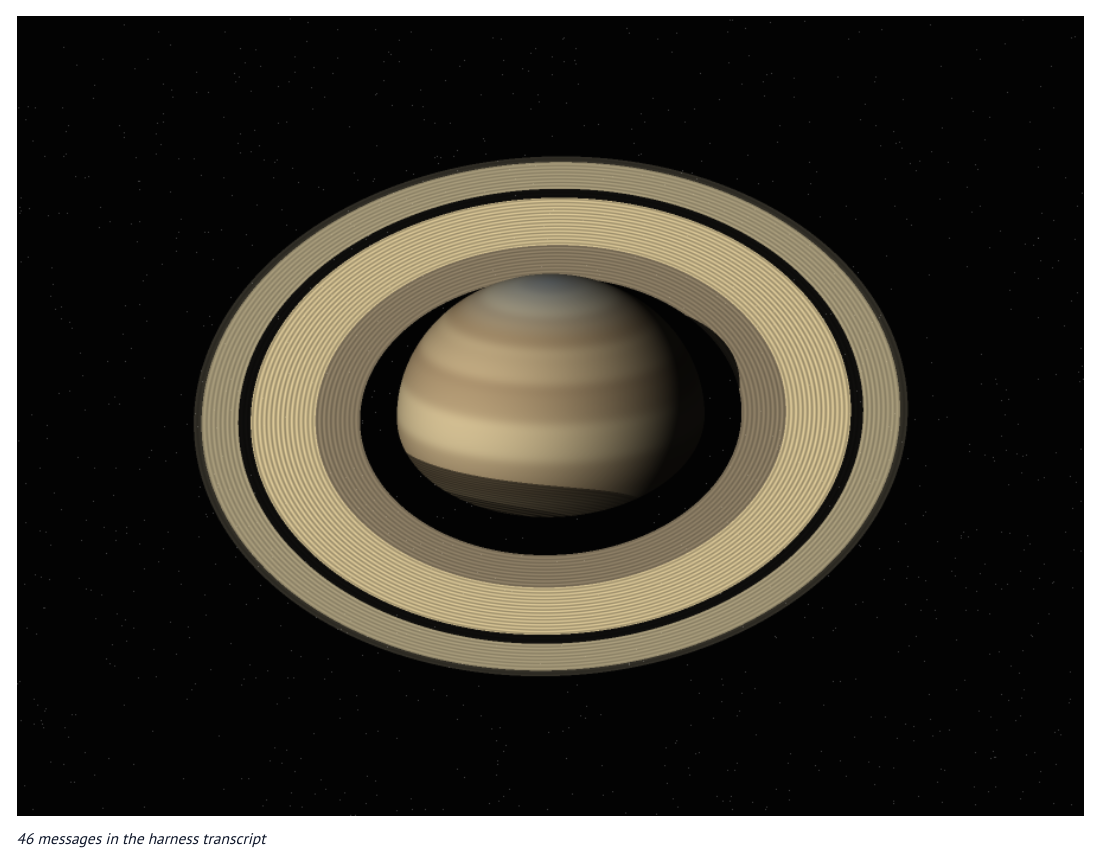

In [ ]:
_png = SATURN_DIR / "saturn.png"
mo.vstack([
    Png(_png.read_bytes()) if _png.exists() else mo.md("**no saturn.png**").callout("warn"),
    mo.md(f"_{len(transcript or [])} messages in the harness transcript_"),
])